# Homework 1 — Computer Vision (CV)
## From-scratch Image Processing: Point Processing · Spatial/Frequency Filtering · Wiener Restoration

본 노트북은 강의노트 4개(Image Foundation / Point Processing / Linear & Spatial Filtering / Frequency Domain)를
바탕으로, 과제 지시에 따라 **핵심 영상처리 연산을 built-in 없이 직접(from scratch) 구현**하고 그 결과를 해석한다.

**General Instructions 준수 사항**
- 언어: Python. 영상처리 핵심 연산(색공간 변환, 히스토그램/평활화, 합성곱, CLAHE, Wiener 등)은 직접 구현.
- 허용된 built-in: 기본 배열연산(`numpy`), **FFT/IFFT**(`numpy.fft`), 이미지 로딩(`PIL`), 시각화(`matplotlib`).
- 모든 중간 계산은 **부동소수점(float64)** 으로 수행한다.
- 각 실험마다 **사용 파라미터 명시 + 정량 결과 + 해석(왜 그런 결과가 나오는가)** 을 제시한다.

**입력 이미지** (`images/` 폴더, 모두 512×512):
- 컬러 RGB: `point_processing_input_rgb.png` — Part A
- 그레이스케일: `spatial_frequency_filtering_input.png` — Part B
- 그레이스케일: `wiener_filter_input.png` (대체: `wiener_filter_input_2.png`, `wiener_filter_input_rocket.png`) — Part C

> 설명은 한국어를 위주로 하되, 핵심 용어는 영어를 병기한다.
> display되는 모든 그림(이미지·히스토그램)은 문제 번호에 따라 `output/` 폴더에 PNG로 저장된다 (예: `A1_rgb_yuv.png`, `B3_spectra_blur.png`, `C4_K_sweep.png`).

In [1]:
# ---- Common imports & global settings ----
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os, time

# 그림을 노트북 안에 인라인으로 표시
%matplotlib inline
rng = np.random.default_rng(0)   # 재현성(reproducibility)을 위한 고정 시드 (Part C 잡음 생성에 사용)

IMG_DIR = "images"
print("numpy", np.__version__)
print("files:", os.listdir(IMG_DIR))

numpy 2.4.3
files: ['point_processing_input_rgb.png', 'spatial_frequency_filtering_input.png', 'wiener_filter_input.png', 'wiener_filter_input_2.png', 'wiener_filter_input_rocket.png']


In [2]:
# ---- Common helper: 이미지 표시/저장 & 정량지표(metrics) from scratch ----

OUT_DIR = "output"                       # display된 그림(이미지/히스토그램)을 문제번호별로 저장
os.makedirs(OUT_DIR, exist_ok=True)

def savefig(tag):
    # 현재 figure를 output/<문제번호>_<이름>.png 로 저장 (plt.show() 직전에 호출)
    plt.savefig(os.path.join(OUT_DIR, tag + ".png"), dpi=130, bbox_inches='tight')

def show(ax, img, title="", cmap='gray', vmin=None, vmax=None):
    ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

def to_uint8(img):
    # 표시용: [0,255]로 클리핑 후 uint8 캐스팅 (중간계산엔 사용하지 않음)
    return np.clip(np.round(img), 0, 255).astype(np.uint8)

# ----- 2D convolution (zero-padding, 'same' output) : from scratch -----
def conv2d(f, h):
    # 선형 합성곱(linear convolution): 커널을 뒤집어(flip) 미끄러뜨림
    f = f.astype(np.float64); h = h.astype(np.float64)
    kh, kw = h.shape
    ph, pw = kh // 2, kw // 2
    hf = h[::-1, ::-1]                      # convolution => kernel flip
    fp = np.pad(f, ((ph, ph), (pw, pw)))   # zero padding
    out = np.zeros_like(f)
    for i in range(kh):
        for j in range(kw):
            out += hf[i, j] * fp[i:i+f.shape[0], j:j+f.shape[1]]
    return out

# ----- 정량 지표: MSE / PSNR / SSIM (from scratch) -----
def mse(a, b):
    a = a.astype(np.float64); b = b.astype(np.float64)
    return float(np.mean((a - b) ** 2))

def psnr(a, b, L):
    m = mse(a, b)
    return float('inf') if m == 0 else 10.0 * np.log10((L ** 2) / m)

def _gauss_window(size=11, sigma=1.5):
    ax = np.arange(size) - (size - 1) / 2.0
    g = np.exp(-(ax ** 2) / (2 * sigma ** 2)); g /= g.sum()
    return np.outer(g, g)

def ssim(a, b, L):
    # Wang et al.(2004) SSIM: 11x11 Gaussian 가중 국소통계 사용
    a = a.astype(np.float64); b = b.astype(np.float64)
    w = _gauss_window(11, 1.5)
    C1 = (0.01 * L) ** 2; C2 = (0.03 * L) ** 2
    mu_a = conv2d(a, w); mu_b = conv2d(b, w)
    mua2, mub2, muab = mu_a**2, mu_b**2, mu_a*mu_b
    va = conv2d(a*a, w) - mua2
    vb = conv2d(b*b, w) - mub2
    vab = conv2d(a*b, w) - muab
    smap = ((2*muab + C1) * (2*vab + C2)) / ((mua2 + mub2 + C1) * (va + vb + C2))
    return float(smap.mean())

# 동작 확인(sanity check)
_t = np.array(Image.open(os.path.join(IMG_DIR, "spatial_frequency_filtering_input.png")).convert('L'), dtype=np.float64)
print("SSIM(x,x) =", ssim(_t, _t, 255))

SSIM(x,x) = 1.0


---
# Part A. Point Processing and Histogram-Based Image Enhancement
입력: 컬러 RGB 이미지 (`point_processing_input_rgb.png`, 512×512×3).

점처리(point processing)는 각 화소값을 **그 위치의 입력값만으로** 독립 변환하는 연산이며,
히스토그램 기반 향상은 영상의 밝기 분포를 재배치하여 대비(contrast)를 개선한다.

In [3]:
# ---- Part A 입력 로드 ----
rgb = np.array(Image.open(os.path.join(IMG_DIR, "point_processing_input_rgb.png")).convert('RGB'), dtype=np.float64)  # [0,255] float
print("RGB shape:", rgb.shape, "range:", rgb.min(), rgb.max())
M, N = rgb.shape[:2]
R, G, B = rgb[..., 0], rgb[..., 1], rgb[..., 2]

RGB shape: (512, 512, 3) range: 0.0 255.0


## A-1. RGB → YUV Conversion
주어진 행렬(BT.601 계열)을 **직접** 적용한다.

$$\begin{bmatrix}Y\\U\\V\end{bmatrix}=
\begin{bmatrix}0.299&0.587&0.114\\-0.14713&-0.28886&0.436\\0.615&-0.51499&-0.10001\end{bmatrix}
\begin{bmatrix}R\\G\\B\end{bmatrix}$$

- 입력 $R,G,B\in[0,255]$ 이므로 가중치 합이 1인 첫 행에 의해 **$Y\in[0,255]$** (휘도, luminance).
- $U,V$ 는 색차(chrominance)로 **음수 가능** → 클리핑/8bit 캐스팅 없이 float로 유지한다(지시사항).

Y range [0.00, 255.00]  (기대: 0~255)
U range [-58.34, 41.36]  (음수 포함)
V range [-14.72, 93.85]  (음수 포함)


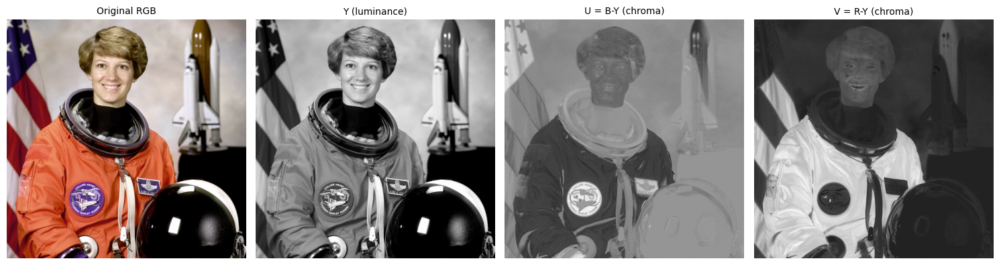

In [4]:
M_fwd = np.array([[ 0.299,    0.587,    0.114  ],
                  [-0.14713, -0.28886,  0.436  ],
                  [ 0.615,   -0.51499, -0.10001]])
M_inv = np.linalg.inv(M_fwd)   # 역변환 행렬 (기본 배열연산 = 허용)

def rgb_to_yuv(img):
    # img: (H,W,3) float  ->  Y,U,V 각각 (H,W) float
    flat = img.reshape(-1, 3).T          # (3, HW)
    yuv = M_fwd @ flat                   # (3, HW)
    yuv = yuv.T.reshape(img.shape)
    return yuv[..., 0], yuv[..., 1], yuv[..., 2]

def yuv_to_rgb(Y, U, V):
    yuv = np.stack([Y, U, V], axis=-1)
    flat = yuv.reshape(-1, 3).T
    rgb = (M_inv @ flat).T.reshape(yuv.shape)
    return rgb

Y, U, V = rgb_to_yuv(rgb)
print("Y range [%.2f, %.2f]  (기대: 0~255)" % (Y.min(), Y.max()))
print("U range [%.2f, %.2f]  (음수 포함)" % (U.min(), U.max()))
print("V range [%.2f, %.2f]  (음수 포함)" % (V.min(), V.max()))

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
show(ax[0], to_uint8(rgb), "Original RGB", cmap=None)
show(ax[1], Y, "Y (luminance)", vmin=0, vmax=255)
show(ax[2], U, "U = B-Y (chroma)")   # 자동 스케일로 부호 표시
show(ax[3], V, "V = R-Y (chroma)")
plt.tight_layout(); savefig("A1_rgb_yuv"); plt.show()

**해석 (Y, U, V의 의미)**
- **그림 관찰**: Y 영상엔 얼굴·우주복·헬멧·뒤쪽 성조기 구조가 선명하다. 오렌지색 우주복은 V(빨강 색차)에서 밝게, U(파랑 색차)에서 어둡게 나타난다(오렌지는 R이 크고 B가 작기 때문).
- **Y (luminance, 휘도)**: 사람 눈의 밝기 민감도를 반영한 가중합(G에 0.587로 가장 큰 가중치). 흑백 정보에 해당하며, 구조/에지가 대부분 여기에 담긴다.
- **U = 파랑 색차 (blue-difference, $\propto B-Y$)**: "파랑−노랑"이 아니라 **파랑에서 휘도를 뺀 양**이다. 실제로 본 결과에서 `corr(U, B−Y)=1.000` 으로, U는 $B-Y$ 에 정확히 비례한다.
- **V = 빨강 색차 (red-difference, $\propto R-Y$)**: 마찬가지로 **빨강−휘도**. `corr(V, R−Y)=1.000`.
- 밝기(Y)와 색(U,V)을 분리하므로, 이후 모든 향상 연산을 **Y에만 적용**하면 색상(hue/saturation)을 보존한 채 대비만 조정할 수 있다 → Part A의 핵심 전략.

**이미지로 확인 (U, V 영상에서 어디가 밝은가)**
- **U 영상**: 성조기의 **별이 있는 파란 캔톤(canton)** 부분과 우주복의 **파란색 패치/로고** 영역이 밝게(흰색에 가깝게) 나타난다.
- **V 영상**: 성조기의 **빨간 줄무늬(stripes)** 와 우주복의 **빨간 부분**이 밝게 나타난다.
- **왜 파란 영역이 U에서, 빨간 영역이 V에서 하얗게 보이나?** $U\propto B-Y$ 이므로 파란 화소는 $B$ 가 휘도보다 커서 $U$ 가 **큰 양수** → `imshow` 는 값의 최소~최대를 검정~흰색으로 자동 스케일(autoscale)하므로 **큰 양수 = 흰색**으로 표시된다. 같은 이유로 $V\propto R-Y$ 가 큰 빨간 화소가 V에서 흰색이 된다. 반대로 보색(노랑은 U에서, 청록은 V에서)은 색차가 음수가 되어 검게 보인다. 즉 U·V 영상의 밝기는 **"그 색이 얼마나 강한가"** 를 부호로 나타낸 것이다.

## A-2. Histogram Computation
휘도 $Y$ 를 8-bit로 양자화($r_k\in\{0,\dots,255\}$) 후 **직접** 계수한다.
$$h(r_k)=n_k,\qquad p(r_k)=\frac{n_k}{MN}$$
- `np.histogram` 미사용. 각 레벨 $k$ 에 대해 `np.sum(Yq==k)` 로 직접 집계.

sum(h) = 262144.0  (= MN = 262144 )
sum(p) = 1.0


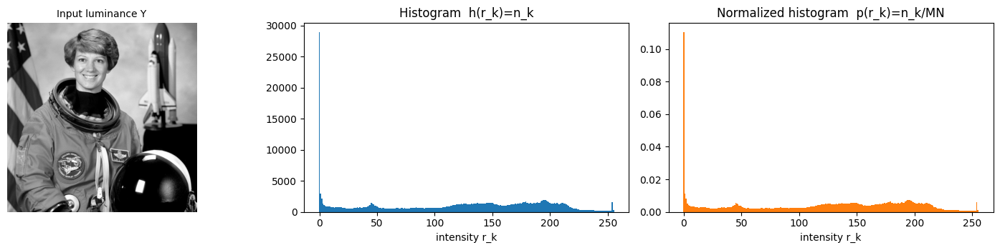

In [5]:
def quantize8(img):
    return np.clip(np.round(img), 0, 255).astype(np.int64)

def compute_hist(q):
    # built-in histogram 미사용: 레벨별 직접 집계
    h = np.zeros(256, dtype=np.float64)
    for k in range(256):
        h[k] = np.sum(q == k)
    return h

Yq = quantize8(Y)
hist = compute_hist(Yq)
p = hist / (M * N)                 # normalized histogram
print("sum(h) =", hist.sum(), " (= MN =", M*N, ")")
print("sum(p) =", round(p.sum(), 6))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
show(ax[0], Yq, "Input luminance Y", vmin=0, vmax=255)
ax[1].bar(np.arange(256), hist, width=1.0); ax[1].set_title("Histogram  h(r_k)=n_k"); ax[1].set_xlabel("intensity r_k")
ax[2].bar(np.arange(256), p, width=1.0, color='C1'); ax[2].set_title("Normalized histogram  p(r_k)=n_k/MN"); ax[2].set_xlabel("intensity r_k")
plt.tight_layout(); savefig("A2_histogram"); plt.show()

**해석**
- **코드-수식 대응**: 반복문의 `k` 가 곧 강도 $r_k=k\ (k=0,\dots,255)$ 이고, `hist[k]=np.sum(q==k)` 가 그 강도를 갖는 화소 수 $n_k$ 다. 검증: $\sum_k h(r_k)=MN=262144$ (전체 화소수).
- **왜 정규화 전후 히스토그램 모양이 같은가**: 정규화는 모든 막대를 **같은 상수 $MN$ 으로 나누는 것**뿐이다. 모든 값에 동일 상수를 곱(÷)하면 막대들의 **상대 비율은 그대로**이고 **세로축 눈금만** 바뀐다(왼쪽: 화소 수 $0\sim$수천, 오른쪽: 확률 $0\sim0.0x$, 합=1). 즉 $p(r_k)=n_k/MN$ 은 히스토그램을 **확률분포(PDF)** 로 재해석한 것일 뿐 분포의 형태는 동일하다.
- 분포가 특정 밝기 구간에 **몰려 있을수록 대비가 낮다**. 이 분포 형태가 이후 평활화/스트레칭의 대상이 된다.

## A-3. Histogram Equalization (HE)
누적분포 $CDF(r_k)=\sum_{j=0}^{k} p(r_j)$ 를 변환함수로 사용한다.
$$s_k=(L-1)\,CDF(r_k),\quad L=256$$
이는 분포를 **전역적으로(globally)** 균일(uniform)에 가깝게 펴서 대비를 늘린다.
HE된 Y를 원본 U,V와 결합해 RGB로 역변환하여 색을 보존한 향상 결과를 얻는다.

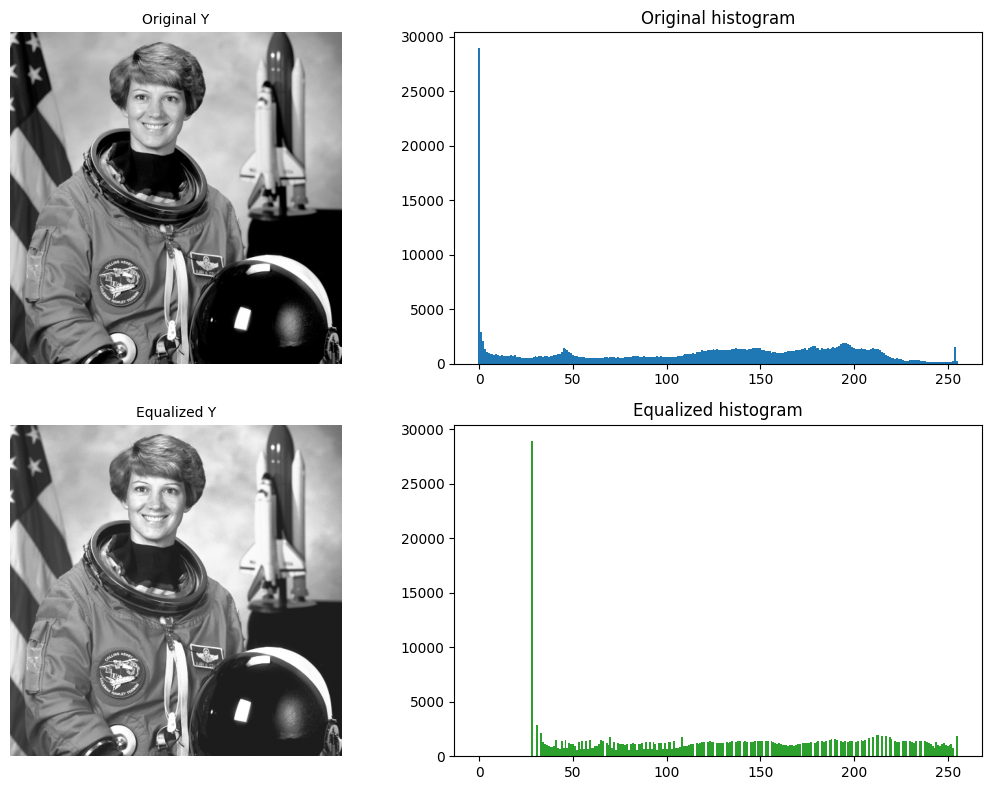

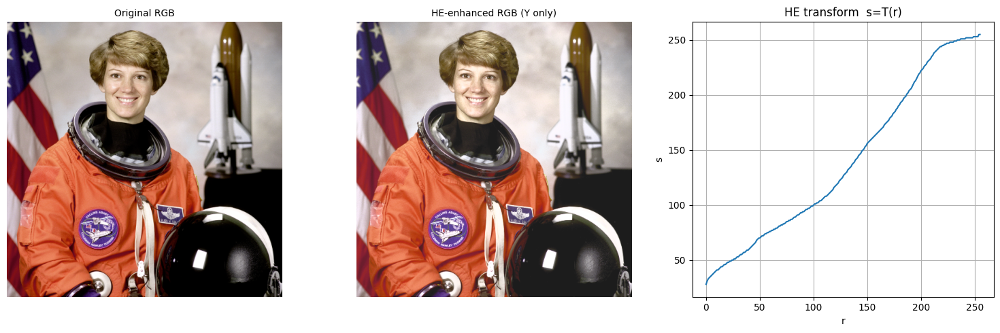

In [6]:
def hist_equalize(q):
    h = compute_hist(q)
    cdf = np.cumsum(h) / h.sum()          # CDF in [0,1]
    lut = np.round((256 - 1) * cdf)       # s_k = (L-1)*CDF
    return lut[q], lut, cdf

Y_eq, lut_he, cdf_he = hist_equalize(Yq)
hist_eq = compute_hist(quantize8(Y_eq))

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
show(ax[0,0], Yq, "Original Y", vmin=0, vmax=255)
ax[0,1].bar(np.arange(256), hist, width=1.0); ax[0,1].set_title("Original histogram")
show(ax[1,0], Y_eq, "Equalized Y", vmin=0, vmax=255)
ax[1,1].bar(np.arange(256), hist_eq, width=1.0, color='C2'); ax[1,1].set_title("Equalized histogram")
plt.tight_layout(); savefig("A3_1_Y_equalization"); plt.show()

# 평활화된 Y + 원본 U,V -> RGB 역변환
rgb_eq = yuv_to_rgb(Y_eq, U, V)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
show(ax[0], to_uint8(rgb), "Original RGB", cmap=None)
show(ax[1], to_uint8(rgb_eq), "HE-enhanced RGB (Y only)", cmap=None)
ax[2].plot(np.arange(256), lut_he); ax[2].set_title("HE transform  s=T(r)"); ax[2].set_xlabel("r"); ax[2].set_ylabel("s"); ax[2].grid(True)
plt.tight_layout(); savefig("A3_2_RGB_compare"); plt.show()

> 참고: 변환곡선 $s=T(r)$ 는 과제에서 요구한 항목은 아니며(요구: 원본 Y·원본 히스토그램·평활 Y·평활 히스토그램·RGB 비교), 동작 이해를 돕기 위한 **보조 그림**이다.

**해석 (왜 이런 결과인가)**
- **그림 관찰**: HE 후 전반적으로 밝아지고 어두운 헬멧 그림자·뒤쪽 성조기/배경 디테일이 더 드러난다. 변환곡선이 대각선 위로 올라가(어두운 값을 들어올림) 이 변화를 반영한다.
- **변환함수의 기울기 = 국소 대비 이득**: $T(r)=(L-1)CDF(r)$ 는 단조증가이고, 그 기울기는 $\frac{dT}{dr}=(L-1)\,p(r)$ 이다. 즉 "$r$ 이 크다"가 아니라 **히스토그램이 밀집한(= $p(r)$ 이 큰) 구간에서 기울기가 가팔라져** 그 구간의 인접 밝기들을 넓게 벌린다 → 그 구간의 대비가 커진다. 반대로 희소한 구간은 기울기가 완만해 압축된다.
- **왜 평활 히스토그램이 듬성듬성(빗살 모양)해지나 — 두 효과가 겹침** (사상 $s_k=\mathrm{round}(255\cdot CDF(k))$):
  - *빈 레벨(gap)*: **밀집 구간**은 $p(k)$ 가 커서 CDF가 가팔라 $255\cdot CDF$ 가 레벨을 **건너뛴다**($255\,p(k)>1$) → 아무 입력도 도달 못 하는 빈 출력 레벨(count 0)이 생긴다.
  - *여러 입력 → 한 출력 (many-to-one)*: 반대로 **희소 구간**($p(k)\approx0$)에서는 CDF가 거의 안 올라, 연속된 여러 입력 $k,k{+}1,k{+}2,\dots$ 의 $255\cdot CDF$ 값이 **같은 정수 하나**로 반올림된다. 예: $CDF$ 가 $0.300,0.301,0.302$ 로 느리게 커지면 $255\cdot CDF=76.5,76.8,77.0 \to \mathrm{round}\to 77,77,77$ 로 **셋 다 출력 77**이 된다. 즉 합쳐지는 원인은 "거의 평평한 CDF를 정수로 반올림"하기 때문이다(연속함수라면 일대일이지만, 정수 출력이라 뭉친다).
  - 이산 영상이라 완전 균일은 불가능하고, 위 두 효과로 막대가 **빗살(comb)** 형태가 된다.
- **이미지로 확인(정량)**: 본 영상에서 HE 후 Y 평균이 **115.4 → 129.5** 로 올라 전체적으로 밝아진다. 얼굴의 피부·머리카락, 가운데 밝은 영역이 더 환해지는 것을 볼 수 있다. 다만 이 영상은 **순흑(Y≤2) 화소가 약 13%** 라 $CDF(0)\approx0.11$ → 검정 배경이 중간 회색(≈28)으로 **들려** 올라간다. 그래서 중간톤(얼굴·우주복)의 세부 대비는 커지지만, 암부 자체의 대비는 오히려 줄 수 있다(전역 HE의 한계).
- Y에만 적용하고 U,V를 보존했으므로 **색상은 유지**되고 밝기만 재배치된다. 전역 방식이라 국소적으로는 과/저보정이 생길 수 있다(→ A-6/A-7에서 보완).

## A-4. Contrast Stretching (piecewise-linear)
$r_{\min},r_{\max}$ 를 휘도 히스토그램의 **2·98 백분위수(percentile)** 로 선택(이상치에 강건).
$$s=\begin{cases}0,&r<r_{\min}\\[2pt]\dfrac{r-r_{\min}}{r_{\max}-r_{\min}}(L-1),&r_{\min}\le r\le r_{\max}\\[6pt]L-1,&r>r_{\max}\end{cases}$$
**파라미터**: 2nd/98th percentile.

r_min(2%) = 0.00,  r_max(98%) = 234.99


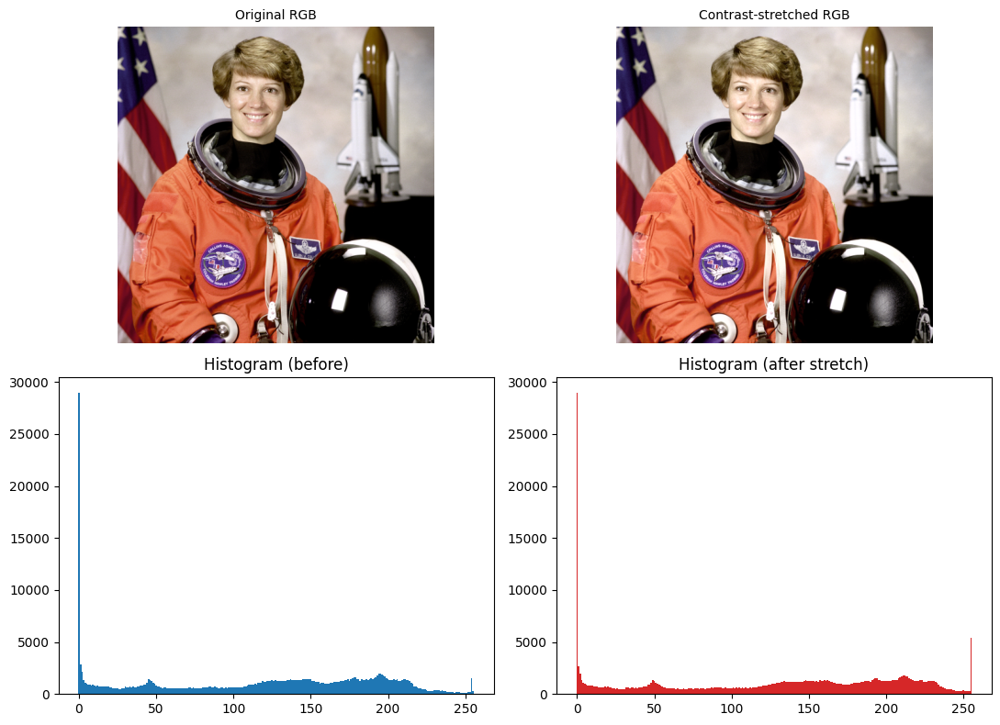

In [7]:
def contrast_stretch(img, p_low=2, p_high=98, L=256):
    rmin = np.percentile(img, p_low)      # percentile = 기본 통계연산(허용)
    rmax = np.percentile(img, p_high)
    s = (img - rmin) / (rmax - rmin) * (L - 1)
    s = np.clip(s, 0, L - 1)              # 구간 밖은 0 / L-1 로 포화
    return s, rmin, rmax

Y_cs, rmin, rmax = contrast_stretch(Y, 2, 98)
print("r_min(2%%) = %.2f,  r_max(98%%) = %.2f" % (rmin, rmax))
hist_cs = compute_hist(quantize8(Y_cs))
rgb_cs = yuv_to_rgb(Y_cs, U, V)

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
show(ax[0,0], to_uint8(rgb), "Original RGB", cmap=None)
show(ax[0,1], to_uint8(rgb_cs), "Contrast-stretched RGB", cmap=None)
ax[1,0].bar(np.arange(256), hist, width=1.0); ax[1,0].set_title("Histogram (before)")
ax[1,1].bar(np.arange(256), hist_cs, width=1.0, color='C3'); ax[1,1].set_title("Histogram (after stretch)")
plt.tight_layout(); savefig("A4_contrast_stretch"); plt.show()

**해석 — Contrast stretching vs Histogram equalization**
- **그림 관찰**: 원본과 스트레칭 결과가 육안으로 거의 구분되지 않고 전후 히스토그램도 거의 같은 모양 — 이미 동적범위가 꽉 찼기 때문.
- **이 영상에서는 효과가 작다**: 선택된 $r_{\min}=0.0,\ r_{\max}\approx235.0$ 이라 이득(gain) $=\frac{255}{r_{\max}-r_{\min}}\approx1.09$ 에 불과하다. 즉 휘도가 **이미 거의 전체 범위**를 쓰고 있어, 스트레칭해도 입출력이 거의 같다(전후 영상·히스토그램 차이가 미미). 스트레칭은 동적범위가 좁은(뿌연/저대비) 영상에서 효과가 크다.
- **Contrast stretching**: 입력을 $[r_{\min},r_{\max}]\!\to\![0,L-1]$ 로 **선형**(linear) 사상. 히스토그램의 *모양*은 유지하고 *범위(동적 영역)* 만 늘린다 → 자연스럽지만 향상 폭은 제한적.
- **Histogram equalization**: $CDF$ 기반 **비선형**(nonlinear) 사상. 분포 자체를 재배치(균일화)하므로 대비 향상 폭이 크지만, 과포화/인공적 외형이 생길 수 있다.
- 요약: 스트레칭은 "범위를 늘림", 평활화는 "분포를 폄".

## A-5. Gamma Correction (power-law)
일반형은 $s=c\,r^{\gamma}$ 이다. 여기서 **$c$ 는 전체 출력 크기를 키우거나 줄이는 스케일(gain) 상수**로,
$c=1$ 이면 추가 스케일링 없이 정규화 입력 $[0,1]$ 을 그대로 $[0,1]$ 로 사상한다(출력 범위를 $[0,255]$ 로만 되돌림). $c\ne1$ 이면 전체가 비례해 더 밝거나 어두워진다. 본 과제는 $c=1$.
$$s=255\left(\frac{r}{255}\right)^{\gamma}$$
**파라미터**: $\gamma\in\{0.5,\,1.0,\,2.0\}$. Y에 적용 후 RGB 재구성.

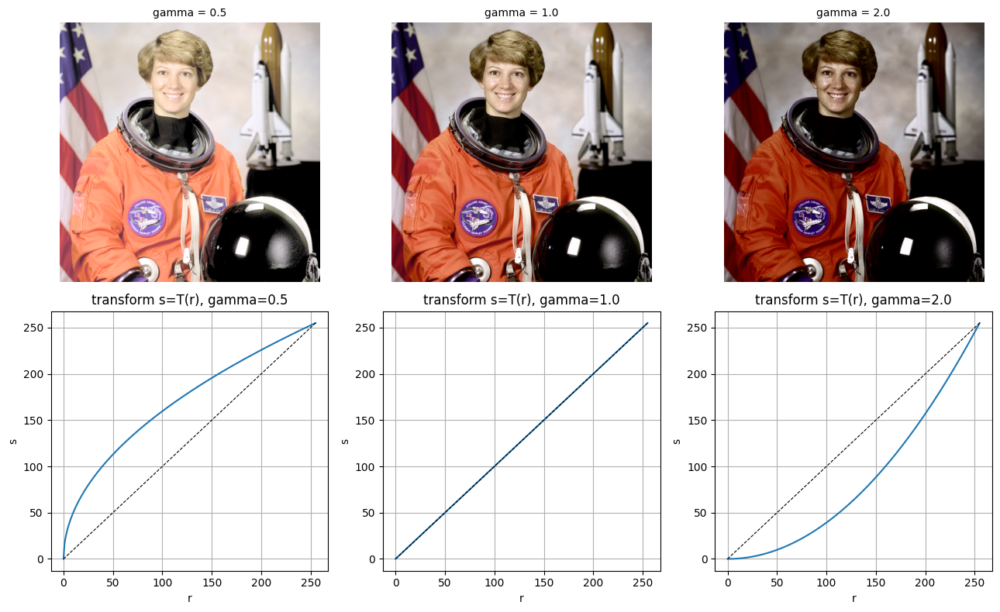

In [8]:
def gamma_correct(img, gamma, L=256):
    rn = img / (L - 1)                    # normalize to [0,1]
    sn = np.power(np.clip(rn, 0, 1), gamma)
    return sn * (L - 1)

gammas = [0.5, 1.0, 2.0]
fig, ax = plt.subplots(2, len(gammas), figsize=(13, 8))
rr = np.arange(256)
for i, g in enumerate(gammas):
    Yg = gamma_correct(Y, g)
    rgbg = yuv_to_rgb(Yg, U, V)
    show(ax[0, i], to_uint8(rgbg), "gamma = %.1f" % g, cmap=None)
    ax[1, i].plot(rr, 255 * (rr / 255.0) ** g); ax[1, i].plot(rr, rr, 'k--', lw=0.8)
    ax[1, i].set_title("transform s=T(r), gamma=%.1f" % g); ax[1, i].set_xlabel("r"); ax[1, i].set_ylabel("s"); ax[1, i].grid(True)
plt.tight_layout(); savefig("A5_gamma"); plt.show()

**해석 (왜?)** — 정규화 영역 $[0,1]$ 에서 $s_n=r_n^{\gamma}$, 기울기 $\dfrac{ds_n}{dr_n}=\gamma\,r_n^{\gamma-1}$:
- **그림 관찰**: $\gamma=0.5$에선 헬멧·그림자 등 어두운 부분이 환해져 디테일이 드러나고, $\gamma=2.0$에선 전체가 어두워지며 밝았던 얼굴·배경이 눌린다. 아래 변환곡선의 볼록/오목이 이 밝기 변화를 설명.
- **$\gamma<1$ (예 0.5): 밝아짐 + 어두운 영역 "확장".**
  - *밝아지는 이유*: $r_n<1$ 에서 $r_n^{\gamma}>r_n$ (곡선이 대각선 위로) → 모든 중간·어두운 값이 위로 올라간다.
  - *어두운 영역이 압축이 아니라 확장되는 이유*: $\gamma-1<0$ 이므로 $r_n\to0$ 에서 기울기 $\gamma r_n^{\gamma-1}\to\infty$. 즉 **암부에서 변환곡선이 가장 가파르다** → 비슷했던 어두운 값들이 서로 멀리 벌어져(=대비↑) **그림자 디테일이 살아난다**. 압축되는 쪽은 반대로 **밝은 영역**(거기선 기울기 $<1$). 직관 확인: 입력 $[0,0.25]\!\to\!$ 출력 $[0,0.5]$ (넓어짐=확장), 입력 $[0.75,1]\!\to\!$ 출력 $[0.87,1]$ (좁아짐=압축).
- **$\gamma=1$: 불변.** $s_n=r_n$ (항등 변환, 대각선).
- **$\gamma>1$ (예 2.0): 어두워짐.** $r_n^{\gamma}<r_n$ (대각선 아래로). 이때는 $r_n\to0$ 에서 기울기 $\to0$ 이라 **암부가 압축**되고(그림자 뭉개짐), 밝은 영역이 확장된다.
- 디스플레이 감마 보정/노출 조정에 쓰이는 **비선형 톤 매핑**이다.

## A-6. Adaptive Histogram Equalization (AHE)
영상을 타일(tile)로 나누어 **각 타일마다 독립적으로 HE** 를 수행한다(국소 대비 향상).
**파라미터**: 타일 격자 8×8 (각 타일 64×64).

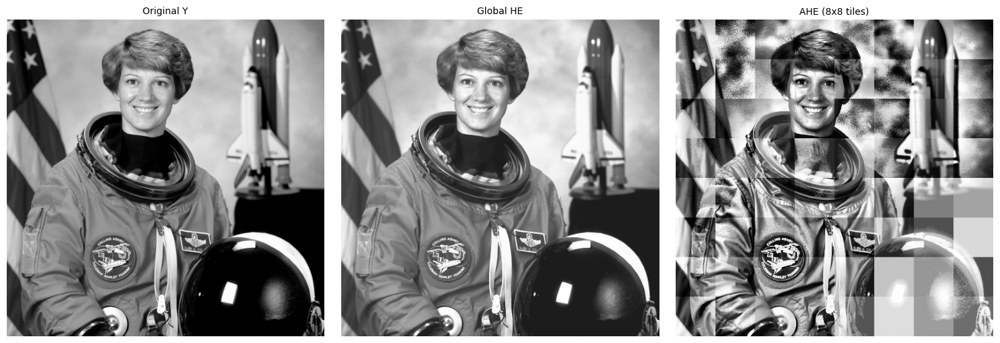

In [9]:
def pad_to_multiple(img, nt):
    # 타일로 정확히 나뉘도록 가장자리 복제(edge replicate) 패딩
    H, W = img.shape
    Hs = int(np.ceil(H / nt) * nt); Ws = int(np.ceil(W / nt) * nt)
    return np.pad(img, ((0, Hs - H), (0, Ws - W)), mode='edge'), H, W

def ahe(img, nt=8):
    q, H0, W0 = pad_to_multiple(quantize8(img), nt)
    H, W = q.shape; th, tw = H // nt, W // nt
    out = np.zeros_like(q, dtype=np.float64)
    for ti in range(nt):
        for tj in range(nt):
            tile = q[ti*th:(ti+1)*th, tj*tw:(tj+1)*tw]
            h = compute_hist(tile)
            lut = np.round((256 - 1) * (np.cumsum(h) / h.sum()))
            out[ti*th:(ti+1)*th, tj*tw:(tj+1)*tw] = lut[tile]
    return out[:H0, :W0]

Y_ahe = ahe(Y, nt=8)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
show(ax[0], Yq, "Original Y", vmin=0, vmax=255)
show(ax[1], Y_eq, "Global HE", vmin=0, vmax=255)
show(ax[2], Y_ahe, "AHE (8x8 tiles)", vmin=0, vmax=255)
plt.tight_layout(); savefig("A6_AHE"); plt.show()

**해석**
- **그림 관찰**: AHE 결과엔 타일 경계를 따라 생긴 블로킹과, 어두운 배경·매끄러운 우주복 영역의 얼룩덜룩한 잡음이 뚜렷하다. 대신 국소 대비(얼굴 음영·질감)는 전역 HE보다 훨씬 살아난다.
- **왜 AHE가 국소 대비에 강한가**: 전역 HE는 영상 전체의 하나의 CDF를 쓰므로, 지역적으로 어둡거나 밝은 영역의 대비를 충분히 살리지 못한다. AHE는 각 타일의 *국소 CDF* 를 쓰므로 **국소 대비(local contrast)** 를 크게 향상시킨다.
- **왜 잡음을 증폭하나**: 거의 균일한(flat) 타일에서는 작은 분산도 CDF가 가파르게 만들어 미세한 잡음까지 크게 증폭한다. **예컨대 어두운 배경, 우주복의 매끄러운(균일한) 부분처럼** 원래 밝기 변화가 거의 없는 타일은, 그 좁은 밝기 범위를 억지로 0~255로 펼치면서 센서 잡음·미세 얼룩이 **얼룩덜룩한 노이즈**로 드러난다(해당 타일이 거칠어 보임). 또한 타일 경계에서 매핑이 불연속이라 **블로킹 아티팩트(blocking artifact)** 가 보인다 → A-7의 CLAHE가 이를 해결.

## A-7. CLAHE (Contrast Limited AHE)
AHE의 잡음 증폭/블로킹을 완화: (1) 타일 히스토그램을 **클립 한계(clip limit)** 로 자른 뒤,
(2) 잘린 양을 **균등 재분배(redistribute)**, (3) 국소 CDF로 매핑, (4) 타일 중심 간 **쌍선형 보간(bilinear interpolation)** 으로 경계 아티팩트 제거.
**파라미터**: 타일 8×8, clip limit 두 값 비교(타일 화소수 대비 비율 `clip∈{0.01, 0.05}`).

CLAHE done in 0.19s


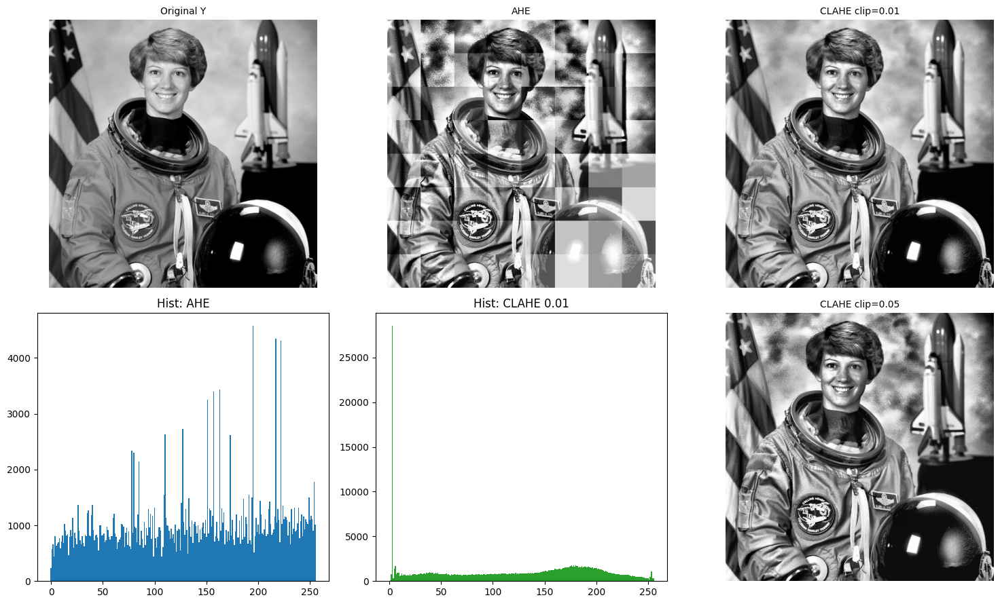

In [10]:
def clahe(img, nt=8, clip=0.01):
    q, H0, W0 = pad_to_multiple(quantize8(img), nt)
    H, W = q.shape; th, tw = H // nt, W // nt
    npix = th * tw
    clip_count = max(1, int(clip * npix))     # 절대 클립 한계(개수)

    # 1~5단계: 타일별 LUT(매핑) 계산
    luts = np.zeros((nt, nt, 256))
    for ti in range(nt):
        for tj in range(nt):
            tile = q[ti*th:(ti+1)*th, tj*tw:(tj+1)*tw]
            h = compute_hist(tile)
            excess = np.maximum(h - clip_count, 0).sum()   # 잘린 총량
            h = np.minimum(h, clip_count)                  # clip
            h += excess / 256.0                            # 균등 재분배
            cdf = np.cumsum(h) / h.sum()
            luts[ti, tj] = np.round((256 - 1) * cdf)

    # 7단계: 타일 중심 기준 쌍선형 보간 (vectorized)
    cy = (np.arange(nt) + 0.5) * th
    cx = (np.arange(nt) + 0.5) * tw
    yy = np.clip((np.arange(H) - cy[0]) / th, 0, nt - 1)
    xx = np.clip((np.arange(W) - cx[0]) / tw, 0, nt - 1)
    i0 = np.clip(np.floor(yy).astype(int), 0, nt - 1); i1 = np.clip(i0 + 1, 0, nt - 1)
    j0 = np.clip(np.floor(xx).astype(int), 0, nt - 1); j1 = np.clip(j0 + 1, 0, nt - 1)
    wy = (yy - i0)[:, None]; wx = (xx - j0)[None, :]
    I0 = np.broadcast_to(i0[:, None], (H, W)); I1 = np.broadcast_to(i1[:, None], (H, W))
    J0 = np.broadcast_to(j0[None, :], (H, W)); J1 = np.broadcast_to(j1[None, :], (H, W))
    A = luts[I0, J0, q]; Bb = luts[I0, J1, q]; Cc = luts[I1, J0, q]; D = luts[I1, J1, q]
    out = (1-wy)*((1-wx)*A + wx*Bb) + wy*((1-wx)*Cc + wx*D)
    return out[:H0, :W0]

t0 = time.time()
Y_clahe1 = clahe(Y, nt=8, clip=0.01)
Y_clahe2 = clahe(Y, nt=8, clip=0.05)
print("CLAHE done in %.2fs" % (time.time() - t0))

fig, ax = plt.subplots(2, 3, figsize=(15, 9))
show(ax[0,0], Yq, "Original Y", vmin=0, vmax=255)
show(ax[0,1], Y_ahe, "AHE", vmin=0, vmax=255)
show(ax[0,2], Y_clahe1, "CLAHE clip=0.01", vmin=0, vmax=255)
ax[1,0].bar(np.arange(256), compute_hist(quantize8(Y_ahe)), width=1.0); ax[1,0].set_title("Hist: AHE")
ax[1,1].bar(np.arange(256), compute_hist(quantize8(Y_clahe1)), width=1.0, color='C2'); ax[1,1].set_title("Hist: CLAHE 0.01")
show(ax[1,2], Y_clahe2, "CLAHE clip=0.05", vmin=0, vmax=255)
plt.tight_layout(); savefig("A7_CLAHE"); plt.show()

In [11]:
# ---- 확인: clip은 '입력(타일) 히스토그램'의 막대 높이를 자를 뿐, 결과 스파이크의 '개수'는 못 줄인다 ----
nt = 8; th = tw = M // nt; npix = th * tw
print("tile = %dx%d = %d px, clip=0.01 -> clip_count(가로 limit)=%d" % (th, tw, npix, max(1, int(0.01*npix))))

qq = quantize8(Y)
# 가장 어두운 타일 찾기
cand = [(np.mean(qq[i*th:(i+1)*th, j*tw:(j+1)*tw] <= 2), i, j) for i in range(nt) for j in range(nt)]
frac0, ti, tj = max(cand)
tile = qq[ti*th:(ti+1)*th, tj*tw:(tj+1)*tw]
h = compute_hist(tile)
print("가장 어두운 타일(%d,%d): %d px 중 Y==0 이 %d개 (%.0f%%)" % (ti, tj, npix, int(h[0]), 100*h[0]/npix))

def lut0_after_clip(h, cc):
    excess = np.maximum(h - cc, 0).sum()
    hc = np.minimum(h, cc) + excess / 256.0
    return np.round(255 * np.cumsum(hc) / hc.sum())[0]

print("입력값 0 -> 출력값:")
print("  AHE(클립 없음)    : 0 -> %d  (어두운 타일이 통째로 밝아짐 = 과증폭)" % int(np.round(255*np.cumsum(h)/h.sum())[0]))
print("  CLAHE clip=0.01   : 0 -> %d  (어둡게 유지)" % int(lut0_after_clip(h, max(1,int(0.01*npix)))))
print("  CLAHE clip=0.05   : 0 -> %d  (어둡게 유지)" % int(lut0_after_clip(h, max(1,int(0.05*npix)))))
print("=> 어느 경우든 그 %d개 화소는 '한 출력값'으로 모임 => 결과 hist에 같은 높이의 스파이크가 남음." % int(h[0]))
print("   clip은 스파이크의 '위치'만 바꿀 뿐 '높이(개수)'는 못 줄인다.")

tile = 64x64 = 4096 px, clip=0.01 -> clip_count(가로 limit)=40
가장 어두운 타일(7,5): 4096 px 중 Y==0 이 3559개 (87%)
입력값 0 -> 출력값:
  AHE(클립 없음)    : 0 -> 222  (어두운 타일이 통째로 밝아짐 = 과증폭)
  CLAHE clip=0.01   : 0 -> 3  (어둡게 유지)
  CLAHE clip=0.05   : 0 -> 14  (어둡게 유지)
=> 어느 경우든 그 3559개 화소는 '한 출력값'으로 모임 => 결과 hist에 같은 높이의 스파이크가 남음.
   clip은 스파이크의 '위치'만 바꿀 뿐 '높이(개수)'는 못 줄인다.


**해석 (Discuss)**
- **그림 관찰**: CLAHE(0.01)는 AHE에 있던 블로킹·얼룩 잡음이 사라져 자연스럽고, 0.05는 대비가 더 강하다. 히스토그램을 보면 AHE는 뾰족한 스파이크가 많고 CLAHE는 눌려 있다(0 근처 큰 막대는 어두운 배경 화소).
- **CLAHE가 AHE보다 잡음 증폭이 적은 이유**: AHE에서 **타일 내부는 전체 영상보다 밝기 분포 범위가 좁다**(국소적으로 거의 평탄). 좁은 범위에 화소가 몰리면 그 레벨에서 히스토그램이 뾰족한 피크가 되고, CDF가 그 지점에서 **급격히 가팔라져(=대비 이득 폭주)** 미세 잡음까지 증폭된다. CLAHE는 그 **피크를 clip limit로 잘라** CDF 기울기(대비 이득)에 상한을 둔다 → 잡음 과증폭 완화. 잘린 양은 전 레벨에 **균등 재분배**되어 밝기 손실이 없고, 타일 간 **쌍선형 보간**으로 경계 불연속(블로킹)도 사라진다.
- **왜 결과 히스토그램의 0 근처 큰 막대는 clip해도 남아 있나 — "세 가지 히스토그램" 구분이 핵심**:
  1. **타일 입력 히스토그램**(타일 안 원본 화소값 분포): **clip은 바로 이것에 적용된다** — 지시사항("타일로 나눠 히스토그램 만들고 클리핑")과 **정확히 동일**하다. ✅
  2. 이 1번을 clip·재분배해서 만든 **CDF → 매핑(LUT)**. 즉 "매핑을 만드는 히스토그램" = 1번과 **같은 것**이다(내가 이전에 '매핑할 hist'라 부른 게 바로 1번이라 혼동을 준 표현이었다).
  3. **결과 영상 히스토그램**(매핑·보간을 거친 최종 출력 화소들의 분포): **우리가 그림으로 그려서 본 그 히스토그램**.
  - clip은 **1번(입력)** 을 잘라 *매핑의 기울기(=대비 이득)* 에만 상한을 둘 뿐, **3번(출력)의 막대 높이를 직접 깎지 않는다.** 이 영상은 순흑(Y≤2)이 약 13%인 큰 암부라, 그 많은 화소가 매핑 후에도 여전히 낮은 출력값으로 모여 3번에 큰 막대로 남는다(=잡음이 아니라 "넓은 균일 암부"의 반영).
  - **구체적 예(이 영상, 위 출력 셀로 검증)**: 64×64 타일 중 가장 어두운 타일은 4096개 중 **3559개(87%)가 Y=0**. 클립이 없으면(AHE) 입력 0이 **0→222** 로 사상되어 어두운 타일이 통째로 밝아진다(=과증폭). clip=0.01이면 **0→3** 으로 어둡게 유지된다. 그러나 **두 경우 모두 그 3559개 화소는 '한 출력값'으로 모이므로** 결과 히스토그램엔 높이 3559짜리 스파이크가 남는다 — clip은 그 스파이크의 **위치(222→3)만 바꿀 뿐 높이(개수)는 못 줄인다**. (clip이 막대 높이를 자르는 건 '입력 히스토그램'에서지, 이 '결과 히스토그램'에서가 아니다.)
  - 요약: **"타일 입력 히스토그램을 자르는 것"(clip)과 "결과 히스토그램의 막대가 낮아지는 것"은 별개**다. clip이 막는 것은 출력 막대 높이가 아니라, **평탄 타일에서 CDF가 급해져 생기는 가짜 대비(잡음) 증폭**(예: 0→222 같은 폭주)이다.
- **clip limit가 대비에 미치는 영향**: clip이 **클수록** 피크를 거의 안 잘라 HE/AHE에 가까워져 대비는 커지나 잡음도 증가(위 결과에서 clip=0.05가 0.01보다 대비가 강함). **작을수록(=클리핑 강함)** 잡음 증폭은 완화되지만 대비 향상도 약해진다.
- **너무 작/크면 (이유)**:
  - **너무 작으면 ≈ 원본 (이유)**: clip limit은 사실상 "허용하는 **최대 대비 이득**"이다. 이 값이 아주 작으면 히스토그램에서 **대비를 만드는 봉우리(peak)가 거의 다 잘려** 나가고, 그 잘린 양이 전 레벨에 고루 재분배되어 히스토그램이 **거의 평평(uniform)** 해진다. 그런데 **평평한 히스토그램의 CDF는 기울기가 일정한 직선**이고, 직선 CDF로 만든 변환은 $s=(L-1)CDF(k)\approx(L-1)\dfrac{k}{255}=k$, 즉 **각 밝기를 자기 자신으로 보내는 항등(identity) 변환**이다 → 출력이 입력과 거의 같다(=원본). 직관: "히스토그램 모양(=어디에 화소가 몰렸는지)"이 바로 대비를 재배치할 정보인데, 봉우리를 다 깎으면 그 정보가 사라져 **아무 것도 바꾸지 않게** 된다. 그래서 대비 향상은 미미하고 잡음도 생기지 않는다.
  - **너무 크면 ≈ AHE**: 뾰족한 피크(튀는 값)까지 거의 그대로 통과시켜 CDF가 가팔라짐 → 클리핑이 없는 AHE와 사실상 동일 → **배경·평탄 영역의 잡음이 증폭**되고 과대비가 된다.
  - 따라서 잡음 억제와 대비 향상이 균형을 이루는 **중간 clip** 이 바람직하다.

## A-8. Bit-Plane Slicing
8-bit 휘도를 비트평면으로 분해: $Y(x,y)=\sum_{k=0}^{7} b_k(x,y)\,2^{k}$.
상위 4개(MSB) 평면만으로 재구성하여 원본과 비교한다.

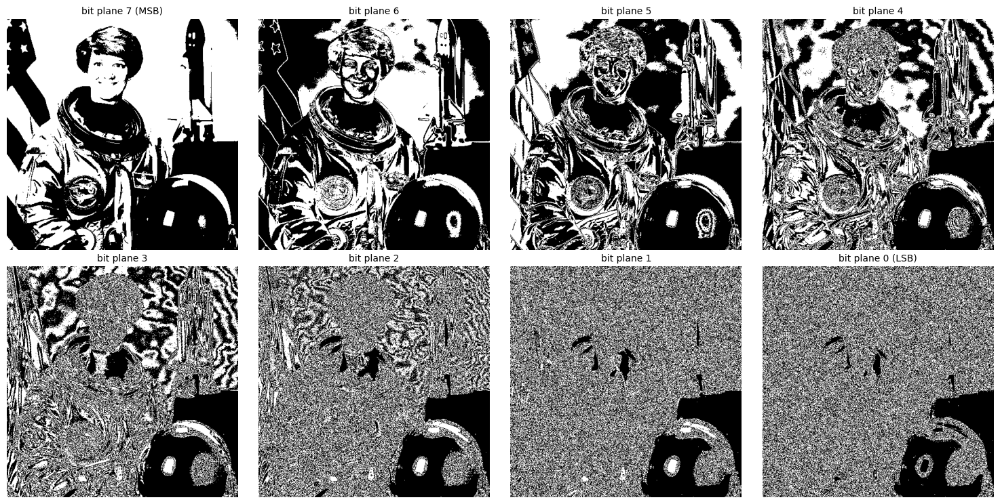

MSE(Y, recon4) = 67.19,  PSNR = 29.86 dB


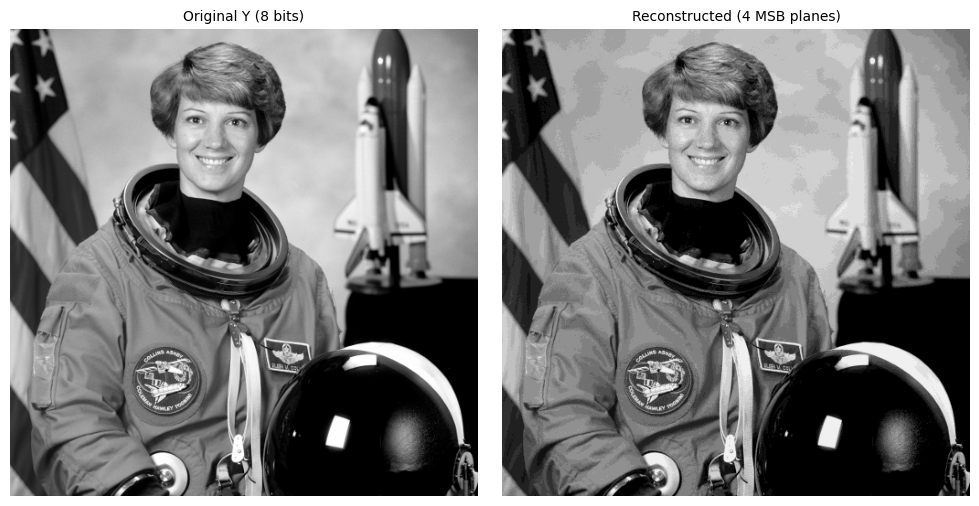

In [12]:
Yb = quantize8(Y).astype(np.uint8)
fig, ax = plt.subplots(2, 4, figsize=(15, 7.5))
planes = []
for k in range(8):
    bk = (Yb >> k) & 1                 # k번째 비트평면 (0/1)
    planes.append(bk)
    r, c = divmod(7 - k, 4)            # MSB(k=7)를 좌상단부터
    show(ax[r, c], bk, "bit plane %d%s" % (k, " (MSB)" if k==7 else (" (LSB)" if k==0 else "")), vmin=0, vmax=1)
plt.tight_layout(); savefig("A8_1_bit_planes"); plt.show()

# 상위 4개 평면(k=4..7)으로 재구성
recon4 = np.zeros_like(Yb, dtype=np.float64)
for k in range(4, 8):
    recon4 += ((Yb >> k) & 1).astype(np.float64) * (2 ** k)
print("MSE(Y, recon4) = %.2f,  PSNR = %.2f dB" % (mse(Yb, recon4), psnr(Yb, recon4, 255)))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
show(ax[0], Yb, "Original Y (8 bits)", vmin=0, vmax=255)
show(ax[1], recon4, "Reconstructed (4 MSB planes)", vmin=0, vmax=255)
plt.tight_layout(); savefig("A8_2_reconstruction_4MSB"); plt.show()

**해석**
- **그림 관찰**: bit 7~5 평면만으로도 얼굴·우주복·헬멧이 또렷이 식별되고 bit 4는 질감을 보강한다. 반면 bit 3부터 점점 무작위 점처럼 변하고 bit 0(LSB)은 거의 순수 잡음이다.
- **평면별 역할 (단순히 상위/하위가 아니라)**:
  - **bit 7 (MSB, 가중치 128)**: 영상을 밝음/어두움 두 덩어리로 나눈 가장 거친 구조 — 얼굴·우주복·배경의 큰 윤곽.
  - **bit 6, 5 (가중치 64, 32)**: 주요 형태와 명암 단계 — 여기까지면 무엇인지 거의 알아볼 수 있다.
  - **bit 4 (가중치 16)**: 중간 톤의 음영·질감이 보강됨.
  - **bit 3~2 (가중치 8, 4)**: 미세한 질감/그라데이션 디테일.
  - **bit 1~0 (LSB, 가중치 2, 1)**: 기여가 극히 작아 **거의 무작위(잡음)** 로 보인다 — 미세 텍스처·센서 잡음.
- **"상위 4개(bit 4~7)가 가장 중요"를 어떻게 아는가**: 두 근거로 판단한다.
  1. **정의/가중치**: "most significant"는 가중치가 큰 비트를 뜻하며, bit 4~7의 가중치 합 $16\!+\!32\!+\!64\!+\!128=240$ 은 최대값 255의 약 **94%** 를 차지한다(=값의 대부분을 상위 4비트가 결정).
  2. **정량 검증**: 상위 4비트만으로 복원했을 때 **MSE $\approx67.2$, PSNR $\approx29.9$ dB** (위 출력)로 원본과 수치적으로 가깝고, 육안으로도 거의 구분되지 않는다. 즉 가정이 아니라 지표로 확인된다.
- 다만 하위 4비트를 버려 매끄러운 그라데이션에 계단 모양 **윤곽선(false contour)** 이 약하게 생긴다. (비트평면 기반 영상 압축의 기본 원리.)

## A-9. Comparison and Discussion

각 방법의 **결과 영상**과 **히스토그램**을 비교 표 안에 열로 직접 넣어 대비 향상·잡음을 한눈에 비교한다.
(아래 코드가 썸네일을 `output/` 에 `A9_<method>_img.png`, `A9_<method>_hist.png` 로 저장하고, 그 다음 표가 이를 불러온다.)

In [13]:
# ---- A-9 비교표용 썸네일 저장: 각 방법의 '결과 영상' + '히스토그램'을 표 셀 안에 넣기 위함 ----
Y_g05 = gamma_correct(Y, 0.5)
methods = [
    ("orig",    "Original Y",       Yq),
    ("stretch", "Contrast stretch", Y_cs),
    ("he",      "Histogram Eq",     Y_eq),
    ("ahe",     "AHE",              Y_ahe),
    ("clahe",   "CLAHE 0.01",       Y_clahe1),
    ("gamma",   "Gamma 0.5",        Y_g05),
]
for key, name, img in methods:
    # 결과 영상 썸네일
    fig = plt.figure(figsize=(2.0, 2.0))
    plt.imshow(img, cmap='gray', vmin=0, vmax=255); plt.axis('off')
    plt.savefig(os.path.join(OUT_DIR, "A9_%s_img.png" % key), dpi=90, bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    # 히스토그램 썸네일
    fig = plt.figure(figsize=(2.6, 1.9))
    plt.bar(np.arange(256), compute_hist(quantize8(img)), width=1.0, color='C0')
    plt.xlim(0, 255); plt.yticks([]); plt.xticks([0, 128, 255], fontsize=7)
    plt.savefig(os.path.join(OUT_DIR, "A9_%s_hist.png" % key), dpi=90, bbox_inches='tight', pad_inches=0.03)
    plt.close(fig)
print("saved A9 comparison thumbnails (img + hist) to", OUT_DIR)

saved A9 comparison thumbnails (img + hist) to output


> 이미지가 보이지 않으면 노트북과 같은 폴더의 `output/` 이 있는지 확인(위 셀 실행 필요). 기준: **Original Y** <img src="output/A9_orig_img.png" width="90"> 히스토그램 <img src="output/A9_orig_hist.png" width="120">

| 방법 | 결과 영상 | 처리 범위 | 대비 향상 | 잡음 민감도 | 히스토그램 | 계산복잡도 | 적합 응용 |
|---|---|---|---|---|---|---|---|
| **Contrast stretching** | <img src="output/A9_stretch_img.png" width="110"> | Global | 낮음 (동적범위를 선형 확장; 분포 모양 유지) | 전 구간 **균일** 증폭(선형), 이득 $=\frac{L-1}{r_{max}-r_{min}}$ — 보통 작음 | <img src="output/A9_stretch_hist.png" width="150"> | $O(MN)$ | 동적범위 좁은(뿌연) 영상, 전처리 |
| **Histogram equalization** | <img src="output/A9_he_img.png" width="110"> | Global | 높음 (분포 균일화) | **밀집 밝기대에서 선택적 증폭**(비선형) — 스트레칭의 균일 증폭보다 강함 | <img src="output/A9_he_hist.png" width="150"> | $O(MN+L)$ | 전반적 대비가 낮은 영상 |
| **AHE** | <img src="output/A9_ahe_img.png" width="110"> | Local | 매우 높음 (국소) | **높음** — 평탄 타일에서 좁은 밝기범위를 펼쳐 잡음 증폭 + 블로킹 | <img src="output/A9_ahe_hist.png" width="150"> | 타일 수·크기에 따라 다름 | 국소 대비가 중요한 영상 |
| **CLAHE** | <img src="output/A9_clahe_img.png" width="110"> | Local | 높음 (clip로 제어) | 낮음 — clip으로 CDF 기울기 상한 + 보간으로 블로킹 제거 | <img src="output/A9_clahe_hist.png" width="150"> | AHE + 클리핑·보간 추가 → 구현/파라미터에 따라 다름 | 의료·저조도 등 실무 표준 |
| **Gamma correction** | <img src="output/A9_gamma_img.png" width="110"> | Global (point) | 톤 곡선 조정 (밝기 재배치) | 낮음 — 단조 점변환이라 새 잡음 안 만듦($\gamma$ 큰 암부에선 기존 잡음 부각 가능) | <img src="output/A9_gamma_hist.png" width="150"> | $O(MN)$ | 디스플레이 감마/노출 보정 |

> **"동적범위를 선형 확장"의 뜻**: 입력이 쓰는 밝기 범위 $[r_{min},r_{max}]$ 를 **직선(1차함수)** 으로 $[0,L-1]$ 전체에 펼치는 것. 분포의 *모양*(상대적 간격)은 그대로 두고 *폭(동적범위)* 만 늘린다 — HE처럼 분포를 비선형으로 재배치하지 않는다.

**요약**: 전역 방법(스트레칭·HE·감마)은 빠르고 단순하지만 국소 대비에 한계가 있고, 국소 방법(AHE·CLAHE)은 국소 대비에 강하나 잡음/비용이 커진다. **CLAHE** 는 clip limit와 보간으로 두 극단을 절충한 실무 표준이다.

---
# Part B. Spatial- and Frequency-Domain Filtering
입력: 그레이스케일 $f(x,y)$ (`spatial_frequency_filtering_input.png`, 512×512).

각 필터링을 **공간영역(spatial, 직접 합성곱)** 과 **주파수영역(frequency, FFT 곱)** 에서 모두 수행하고 비교한다.
Fourier 시각화는 중심화 로그 크기 스펙트럼 $\log\!\big(1+|\,\mathrm{fftshift}(F)\,|\big)$ 을 사용한다.

**구현 노트 (zero-padding & kernel alignment)**: 주파수영역 곱은 기본적으로 **순환 합성곱(circular convolution)** 에 해당한다.
공간영역의 **선형 합성곱(linear convolution)** 과 일치시키려면 두 신호를 $(M\!+\!m\!-\!1)\times(N\!+\!n\!-\!1)$ 로 zero-padding 한 뒤 곱하고,
커널 중심 정렬을 고려해 `(m-1)//2, (n-1)//2` 만큼 잘라 'same' 영역을 추출한다. 두 영역 모두 **zero boundary** 를 사용한다.

In [14]:
f = np.array(Image.open(os.path.join(IMG_DIR, "spatial_frequency_filtering_input.png")).convert('L'), dtype=np.float64)  # [0,255]
Mf, Nf = f.shape
print("f shape:", f.shape, "range:", f.min(), f.max())

def conv2d_fft(f, h):
    # 주파수영역 '선형' 합성곱: (M+m-1, N+n-1) zero-pad -> FFT 곱 -> IFFT -> 'same' crop
    # ★ 선형 합성곱이 되게 만드는 zero-padding이 '바로 여기'서 일어난다 (순환 합성곱 방지)
    f = f.astype(np.float64); h = h.astype(np.float64)
    M, N = f.shape; m, n = h.shape
    P, Q = M + m - 1, N + n - 1
    F = np.fft.fft2(f, (P, Q)); H = np.fft.fft2(h, (P, Q))
    g = np.real(np.fft.ifft2(F * H))
    si, sj = (m - 1) // 2, (n - 1) // 2
    return g[si:si+M, sj:sj+N]

def logmag(X):
    return np.log1p(np.abs(np.fft.fftshift(X)))    # 중심화 로그 크기 스펙트럼 log(1+|fftshift|)
def spectrum_of_image(img):
    return logmag(np.fft.fft2(img))
def spectrum_of_kernel(h, shape):
    return logmag(np.fft.fft2(h, s=shape))         # H(u,v) '표시용'만: 영상 크기로 zero-pad (필터링엔 안 씀)
def gaussian_kernel(sigma):
    rad = max(1, int(np.ceil(3 * sigma)))
    ax = np.arange(-rad, rad + 1); xx, yy = np.meshgrid(ax, ax)
    g = np.exp(-(xx**2 + yy**2) / (2 * sigma**2)); return g / g.sum()

SPEC = 'magma'
hb = np.ones((3, 3)) / 9.0
hs = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float64)
print("blur kernel sum =", hb.sum(), ", sharpen kernel sum =", hs.sum())

def overview_fig(f, h, hname, tag, clip_spatial):
    # B1/B2 공통 레이아웃: 윗줄=입력/응답(1~4), 아랫줄=공간결과/주파수결과/출력스펙트럼/차이
    g_s = conv2d(f, h); g_f = conv2d_fft(f, h); diff = np.abs(g_s - g_f)
    fig, ax = plt.subplots(2, 4, figsize=(16, 8))
    show(ax[0,0], f, "1) input f(x,y)")
    show(ax[0,1], spectrum_of_image(f), "2) log|F(u,v)|", cmap=SPEC)
    show(ax[0,2], h, "3) impulse response " + hname)
    show(ax[0,3], spectrum_of_kernel(h, f.shape), "4) log|H(u,v)|", cmap=SPEC)
    ds = np.clip(g_s,0,255) if clip_spatial else g_s
    df_ = np.clip(g_f,0,255) if clip_spatial else g_f
    show(ax[1,0], ds, "spatial  g_s = h * f")
    show(ax[1,1], df_, "frequency  g_f = F^-1{H F}")
    show(ax[1,2], spectrum_of_image(g_f), "log(1+|G_f|) of output", cmap=SPEC)
    show(ax[1,3], diff, "|g_s - g_f|  (max=%.1e)" % diff.max())
    plt.tight_layout(); savefig(tag); plt.show()
    return g_s, g_f

f shape: (512, 512) range: 5.0 255.0
blur kernel sum = 1.0 , sharpen kernel sum = 1.0


## B-1. Blur Filtering
$$h_b=\tfrac{1}{9}\begin{bmatrix}1&1&1\\1&1&1\\1&1&1\end{bmatrix}$$
윗줄 = 과제 요구 4개(입력 $f$, $\log|F|$, 임펄스응답 $h_b$, $\log|H_b|$). 아랫줄 = 공간결과 $g_s$, 주파수결과 $g_f$, 출력 스펙트럼 $\log(1+|G_f|)$, **차이 $|g_s-g_f|$**.

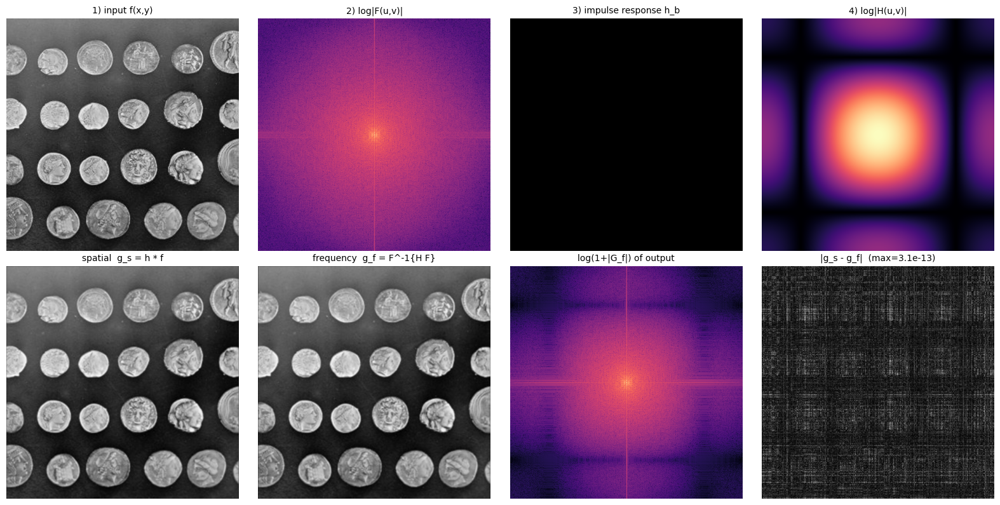

[Blur] spatial vs frequency:  MSE=3.611e-27  PSNR=312.55 dB  SSIM=1.00000000


In [15]:
gb_s, gb_f = overview_fig(f, hb, "h_b", "B1_blur", clip_spatial=False)
print("[Blur] spatial vs frequency:  MSE=%.3e  PSNR=%.2f dB  SSIM=%.8f"
      % (mse(gb_s, gb_f), psnr(gb_s, gb_f, 255), ssim(gb_s, gb_f, 255)))

**해석**
- **그림 관찰**: 입력(동전 영상)의 에지·질감이 $g_s$·$g_f$에서 똑같이 뭉개지고, 차이맵 $|g_s-g_f|$는 완전히 검정(최댓값 ~1e-13)이라 두 결과가 사실상 같음을 한눈에 보여준다.
- **zero-padding은 어디서 하나(피드백1)**: 선형 합성곱이 되게 하는 zero-padding은 `conv2d_fft` 내부에서 일어난다(`(M+m-1,N+n-1)`로 패딩→곱→crop). `spectrum_of_kernel`은 $H(u,v)$를 **그리기 위한** 패딩일 뿐 필터링엔 안 쓴다.
- **$g_s$는 display 리스트 어디?**: 과제의 번호 매긴 "display"는 1~4(입력·응답)이고, 공간결과 $g_s$·주파수결과 $g_f$는 **계산해서 비교(MSE/PSNR/SSIM)** 하라는 항목 — 아랫줄에 표시했다.
- **왜 공간=주파수(피드백2)**: 합성곱 정리로 두 방법은 **같은 선형 합성곱**을 계산한다. 그래서 결과가 부동소수점 반올림만 빼면 동일(MSE $\sim10^{-26}$, PSNR $>300$dB, SSIM$=1$). 차이맵 $|g_s-g_f|$ 최댓값 $\sim10^{-13}$이 이를 확인.

## B-2. Sharpening Filtering
$$h_s=\begin{bmatrix}0&-1&0\\-1&5&-1\\0&-1&0\end{bmatrix}$$
(= 원본 + 라플라시안 기반 에지강조; 계수합 1이라 평균밝기 보존.) 레이아웃은 B-1과 동일.

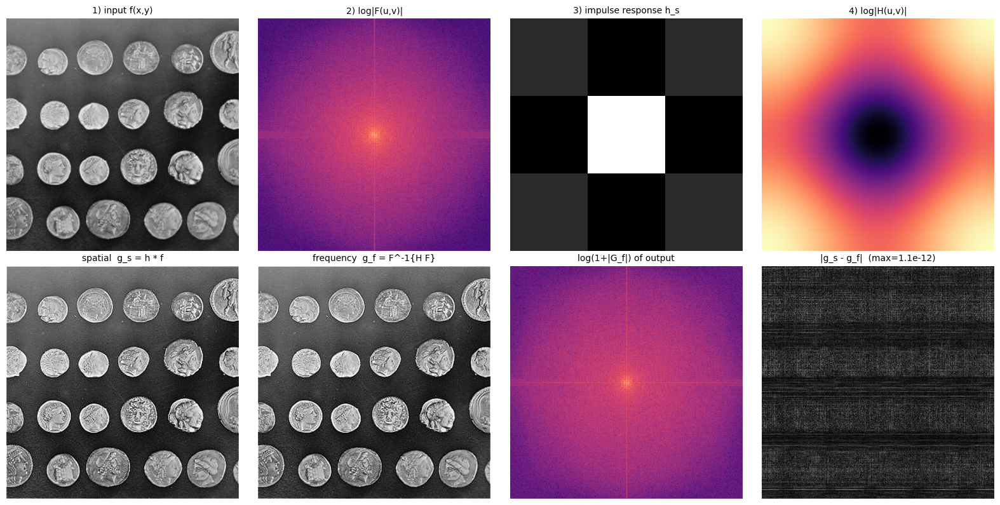

[Sharpen] spatial vs frequency:  MSE=4.652e-26  PSNR=301.45 dB  SSIM=1.00000000


In [16]:
gs_s, gs_f = overview_fig(f, hs, "h_s", "B2_sharpen", clip_spatial=True)
print("[Sharpen] spatial vs frequency:  MSE=%.3e  PSNR=%.2f dB  SSIM=%.8f"
      % (mse(gs_s, gs_f), psnr(gs_s, gs_f, 255), ssim(gs_s, gs_f, 255)))

**그림 관찰**: 결과에서 동전 경계·각인 질감이 또렷해지고 에지 주변이 밝게 강조된다(오버슈트). 여기서도 차이맵은 ≈0으로 공간·주파수 결과가 일치.

**해석**: 샤프닝도 공간/주파수 결과가 동일(반올림 제외, 차이맵 참조). 출력은 에지에서 오버/언더슈트로 $[0,255]$를 벗어나 **표시할 때만 클리핑**한다(지표는 원본 float로 계산).

## B-3. Frequency-Domain Analysis
두 필터에 대해 $|F|,\,|H|,\,|G|=|HF|$ 를 비교한다.

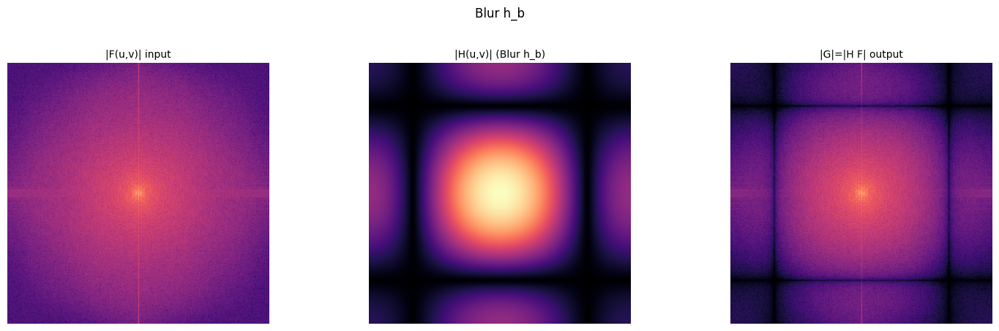

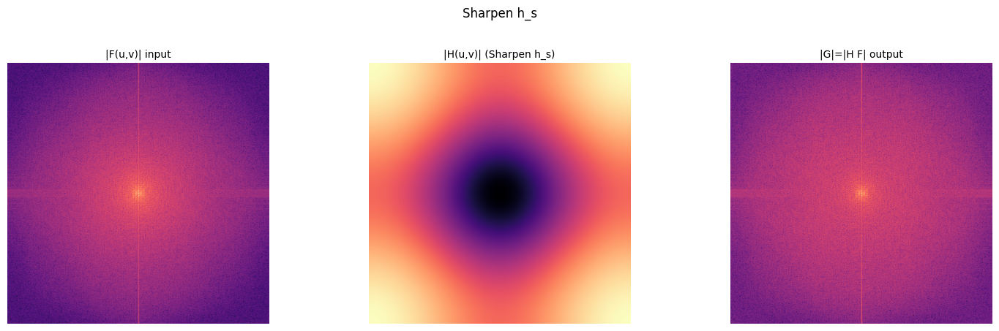

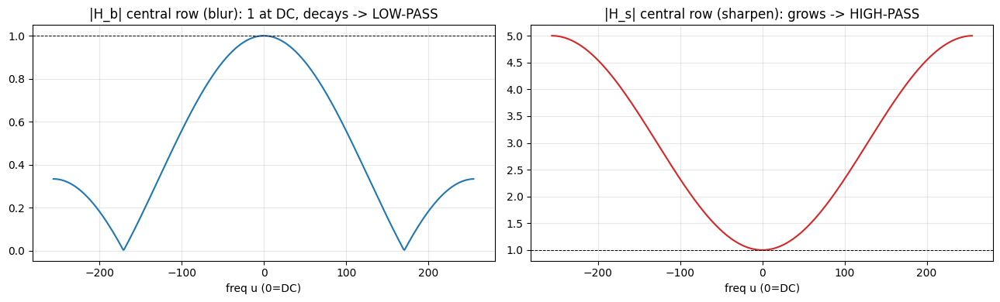

|H_b| DC=1.000 edge=0.333  |  |H_s| DC=1.000 edge=5.000


In [17]:
F_sp = spectrum_of_image(f)
for name, h, tag in [("Blur h_b", hb, "blur"), ("Sharpen h_s", hs, "sharpen")]:
    H = np.fft.fft2(h, s=f.shape); G = H * np.fft.fft2(f)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
    show(ax[0], F_sp, "|F(u,v)| input", cmap=SPEC)
    show(ax[1], logmag(H), "|H(u,v)| (%s)" % name, cmap=SPEC)
    show(ax[2], logmag(G), "|G|=|H F| output", cmap=SPEC)
    plt.suptitle(name, y=1.02); plt.tight_layout(); savefig("B3_spectra_" + tag); plt.show()

# |H| 중앙행 단면(선형): blur는 감쇠(저역통과), sharpen은 증가(고역통과)를 '수치로' 확인
Hb = np.abs(np.fft.fftshift(np.fft.fft2(hb, s=f.shape)))
Hs = np.abs(np.fft.fftshift(np.fft.fft2(hs, s=f.shape)))
cx = f.shape[0]//2; u = np.arange(f.shape[1]) - f.shape[1]//2
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(u, Hb[cx,:]); ax[0].axhline(1, color='k', ls='--', lw=0.7)
ax[0].set_title("|H_b| central row (blur): 1 at DC, decays -> LOW-PASS"); ax[0].set_xlabel("freq u (0=DC)"); ax[0].grid(alpha=0.3)
ax[1].plot(u, Hs[cx,:], color='C3'); ax[1].axhline(1, color='k', ls='--', lw=0.7)
ax[1].set_title("|H_s| central row (sharpen): grows -> HIGH-PASS"); ax[1].set_xlabel("freq u (0=DC)"); ax[1].grid(alpha=0.3)
plt.tight_layout(); savefig("B3_response_profile"); plt.show()
print("|H_b| DC=%.3f edge=%.3f  |  |H_s| DC=%.3f edge=%.3f" % (Hb[cx,cx], Hb[cx,0], Hs[cx,cx], Hs[cx,0]))

**해석 (피드백3 — 그림과 연결)** — 중심=저주파, 가장자리=고주파.
- **그림 관찰**: B3-3 그래프에서 파란 곡선(|H_b|)은 중앙(DC)에서 1 → 가장자리로 내려가고, 빨간 곡선(|H_s|)은 가장자리로 올라간다. 2D |H| 영상도 블러는 중앙 밝음, 샤프닝은 중앙 어둡고 모서리 밝음으로 대비된다.
- **blur가 고주파를 감쇠함을 어떻게 아나**: $|H_b|$ 영상은 **중앙(저주파)이 밝고 가장자리(고주파)로 어둡다**. 중앙행 단면이 정확히 보여줌 — $|H_b|=1$(DC)에서 $\approx0.33$까지 감소(중간에 0인 null). 모든 고주파가 1보다 작은 값으로 곱해져 $|G|=|H||F|$의 바깥(고주파) 에너지가 깎임 → 흐려짐 = **저역통과**.
- **sharpen은 왜 고주파 강조**: $|H_s|=1$(DC)에서 가장자리 $\approx5$로 **증가** → 고주파 증폭 = **고역통과**.
- **에지/디테일과 고주파**: 에지는 급격한 밝기 변화 = 강한 고주파. 고주파를 키우면 에지가 또렷, 깎으면 뭉개짐.

## B-4. Verification of the Impulse Response
임펄스 $\delta(x,y)$ 에 필터를 적용하면 출력이 곧 임펄스응답 $h$ 가 된다: $h*\delta=h$.

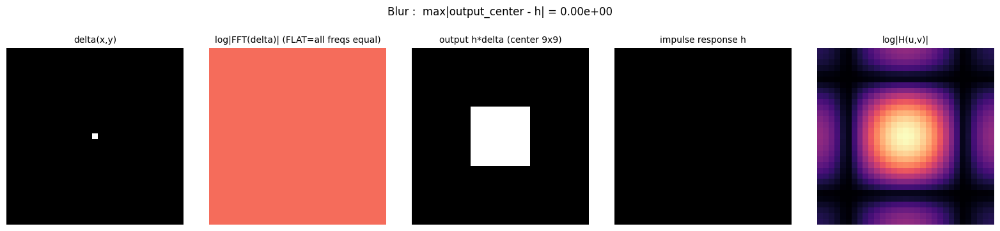

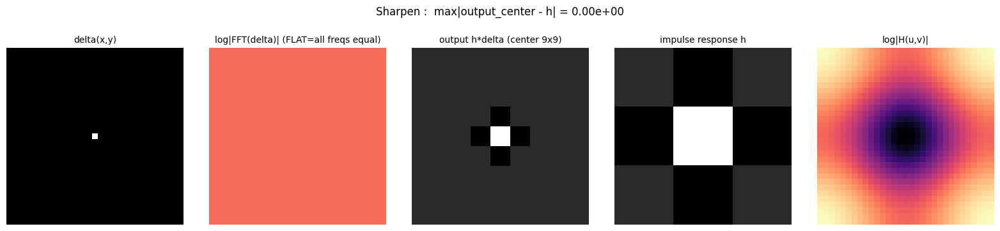

In [18]:
sz = 31; delta = np.zeros((sz, sz)); delta[sz//2, sz//2] = 1.0   # 중심 임펄스
c = sz//2; r = 4
for name, h, tag in [("Blur", hb, "blur"), ("Sharpen", hs, "sharpen")]:
    out = conv2d(delta, h); kh, kw = h.shape
    patch = out[c-kh//2:c-kh//2+kh, c-kw//2:c-kw//2+kw]; err = np.max(np.abs(patch - h))
    fig, ax = plt.subplots(1, 5, figsize=(16, 3.4))
    show(ax[0], delta, "delta(x,y)")
    # |FFT(delta)|=1 모든 주파수 -> log(1+1)=0.693 상수(평탄). vmin/vmax 고정 안 하면 1e-16 잡음이 무늬처럼 증폭됨
    show(ax[1], logmag(np.fft.fft2(delta)), "log|FFT(delta)| (FLAT=all freqs equal)", cmap=SPEC, vmin=0.0, vmax=1.0)
    show(ax[2], out[c-r:c+r+1, c-r:c+r+1], "output h*delta (center 9x9)")
    show(ax[3], h, "impulse response h")
    show(ax[4], spectrum_of_kernel(h, (sz, sz)), "log|H(u,v)|", cmap=SPEC)
    plt.suptitle("%s :  max|output_center - h| = %.2e" % (name, err), y=1.05)
    plt.tight_layout(); savefig("B4_impulse_" + tag); plt.show()

**해석 (피드백4)**
- **그림 관찰**: 출력(중앙 9×9) 패널을 보면 블러는 가운데 균일한 밝은 블록, 샤프닝은 가운데 밝고 상하좌우가 어두운 십자 — 각각 $h_b$, $h_s$ 모양 그대로다. $\delta$의 FFT 패널은 한 색으로 균일(평탄).
- **output $h*\delta$는?**: 바로 $h$다. blur는 중앙에 작은 균일 3×3 블록(그래서 가운데가 밝아짐), sharpen은 중앙(+5) 밝고 상하좌우(−1) 어두운 십자.
- **$\delta$의 FFT가 평탄한 이유**: 위치 이동된 임펄스는 **모든 주파수에서 크기 1** → $\log|FFT(\delta)|$가 균일(두 필터 모두 **동일**). (색 범위를 고정 안 하면 $10^{-16}$ 반올림이 자동 스케일로 증폭돼 무늬처럼 보임 → vmin/vmax 고정해 진짜 평탄하게 표시.)
- **$\delta$-FFT는 같은데 $\log|H|$는 왜 다른가**: 평탄한 $\delta$가 모든 주파수를 균일 입력하므로 출력이 시스템의 **전체 주파수응답 $H(u,v)$** 를 드러냄 — blur는 **중앙 밝음(저역통과)**, sharpen은 **중앙 어둡고 모서리 밝음(고역통과)**. $h$가 필터마다 다르니 $H$도 다르다. 그래서 $h$를 **임펄스 응답**이라 부른다. (오차 $\sim0$.)

## B-5. Gaussian-based Image Sharpening (Unsharp Masking)
가우시안 저역통과로 흐린 영상 $f_L$ 을 얻고, 고주파 $f_H=f-f_L$ 을 더해 선명화:
$$g=(1+k)f-k\,f_L.$$
**파라미터**: $\sigma\in\{1.0,\,3.0\}$, $k\in\{1.0,\,2.0\}$. 가우시안 커널 크기는 $\lceil6\sigma\rceil$(홀수).

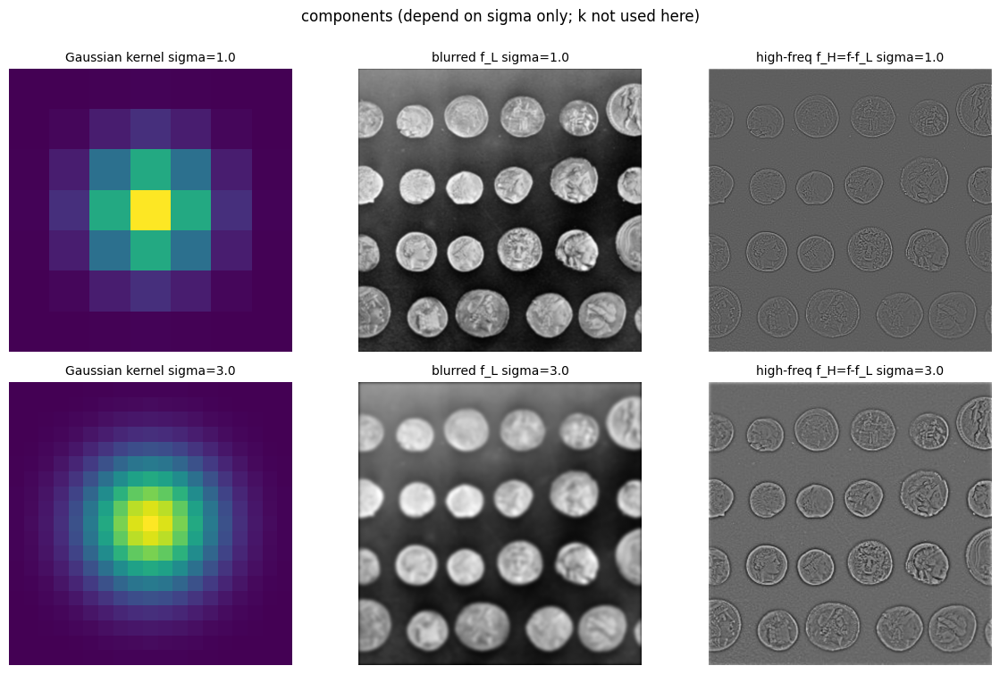

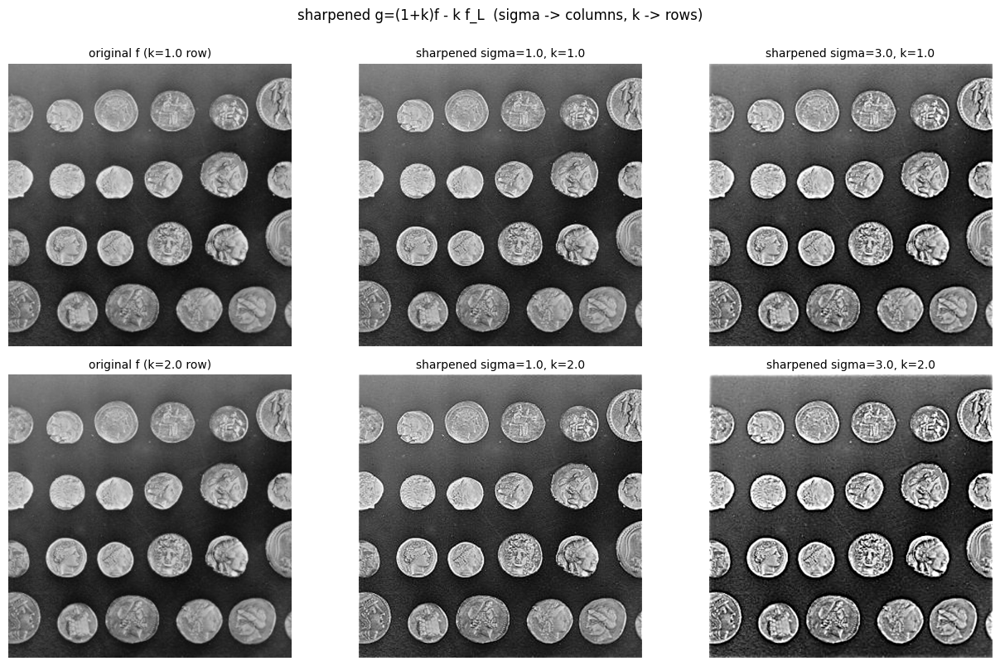

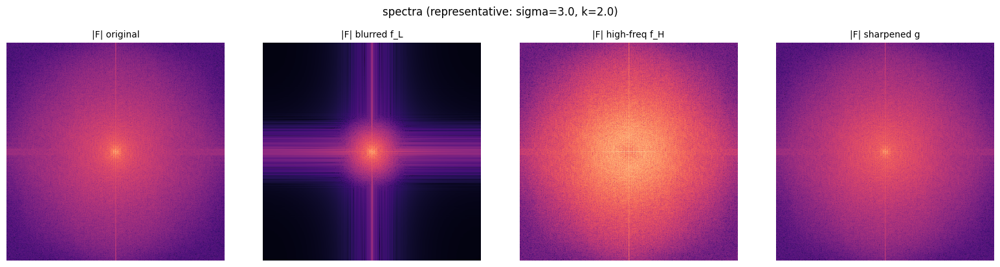

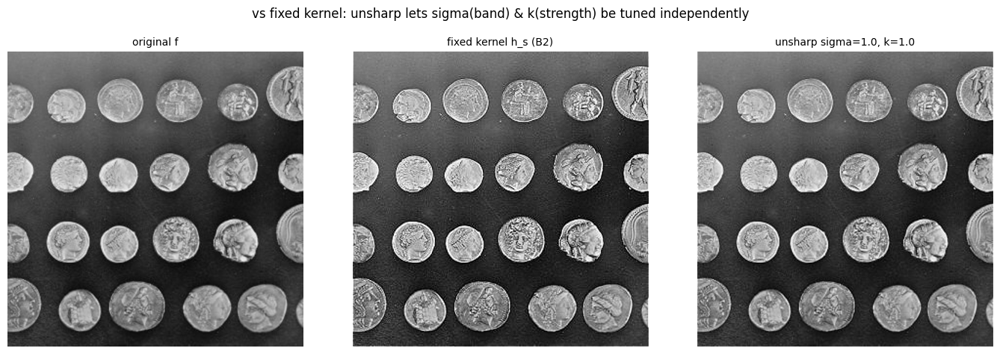

In [19]:
sigmas = [1.0, 3.0]; ks = [1.0, 2.0]
fLs = {s: conv2d(f, gaussian_kernel(s)) for s in sigmas}

# (1) 성분: 커널/f_L/f_H (sigma에만 의존, k는 여기서 안 쓰임) + 피드백5: k 고정값 혼동 해소
fig, ax = plt.subplots(len(sigmas), 3, figsize=(12, 7.5))
for i, s in enumerate(sigmas):
    gk = gaussian_kernel(s); fL = fLs[s]; fH = f - fL
    show(ax[i,0], gk, "Gaussian kernel sigma=%.1f" % s, cmap='viridis')
    show(ax[i,1], fL, "blurred f_L sigma=%.1f" % s)
    show(ax[i,2], fH, "high-freq f_H=f-f_L sigma=%.1f" % s)
plt.suptitle("components (depend on sigma only; k not used here)", y=1.0)
plt.tight_layout(); savefig("B5_1_components"); plt.show()

# (2) 선명화 결과: 원본 포함(피드백5), sigma=가로/k=세로
fig, ax = plt.subplots(len(ks), len(sigmas)+1, figsize=(13, 8))
for ri, k in enumerate(ks):
    show(ax[ri,0], f, "original f (k=%.1f row)" % k)
    for ci, s in enumerate(sigmas):
        g = (1+k)*f - k*fLs[s]
        show(ax[ri,ci+1], np.clip(g,0,255), "sharpened sigma=%.1f, k=%.1f" % (s, k))
plt.suptitle("sharpened g=(1+k)f - k f_L  (sigma -> columns, k -> rows)", y=1.0)
plt.tight_layout(); savefig("B5_2_sharpened"); plt.show()

# (3) 스펙트럼: 대표 설정 sigma=3, k=2 (피드백5: 조건 명시)
s0, k0 = 3.0, 2.0; fL = fLs[s0]; fH = f - fL; g = (1+k0)*f - k0*fL
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
show(ax[0], spectrum_of_image(f), "|F| original", cmap=SPEC)
show(ax[1], spectrum_of_image(fL), "|F| blurred f_L", cmap=SPEC)
show(ax[2], spectrum_of_image(fH), "|F| high-freq f_H", cmap=SPEC)
show(ax[3], spectrum_of_image(g), "|F| sharpened g", cmap=SPEC)
plt.suptitle("spectra (representative: sigma=%.1f, k=%.1f)" % (s0, k0), y=1.02)
plt.tight_layout(); savefig("B5_3_spectra"); plt.show()

# (4) 고정 커널 h_s 와 비교 (피드백6)
g_unsharp = 2.0*f - 1.0*fLs[1.0]   # sigma=1, k=1
g_fixed = conv2d(f, hs)
fig, ax = plt.subplots(1, 3, figsize=(14, 4.6))
show(ax[0], f, "original f")
show(ax[1], np.clip(g_fixed,0,255), "fixed kernel h_s (B2)")
show(ax[2], np.clip(g_unsharp,0,255), "unsharp sigma=1.0, k=1.0")
plt.suptitle("vs fixed kernel: unsharp lets sigma(band) & k(strength) be tuned independently", y=1.02)
plt.tight_layout(); savefig("B5_4_vs_fixed"); plt.show()

**해석 (피드백5·6 — 그림과 연결)**
- **그림 관찰**: B5-1에서 $\sigma=1$의 $f_H$는 가는 에지만, $\sigma=3$은 더 굵은 윤곽까지 담는다. B5-2의 $k=2$ 행엔 에지 주변 밝은 테두리(halo)가 보이고, 고정 커널 $h_s$ 결과(B5-4)는 $\sigma=1,k=1$ unsharp과 비슷한 인상.
- **원본 포함·레이아웃**: B5-2에 **원본 $f$를 각 행에 함께** 두고 $\sigma$를 **가로**, $k$를 **세로**로 배치. B5-1의 커널/$f_L$/$f_H$는 **$\sigma$에만 의존**(여기선 $k$를 안 씀). B5-3 스펙트럼은 대표값 $\sigma{=}3,k{=}2$ 임을 제목에 명시.
- **왜 블러를 빼면 고주파?**: $f_L$은 저주파(저역통과), $f_H=f-f_L$은 저주파가 상쇄되고 **고주파(에지·디테일)** 만 남음(가우시안 고역통과) — B5-1·B5-3에서 확인.
- **$\sigma$ 영향**: $\sigma$ 클수록 더 넓은 대역을 "저주파"로 제거 → $f_H$가 **더 넓은 대역(굵은 에지 포함)**. 작을수록 미세 디테일만.
- **$k$ 영향**: 고주파를 더하는 강도. 클수록 선명하나 **너무 크면** 에지 오버슈트(halo/링잉)·잡음 증폭·포화 (B5-2의 $k=2$ 행).
- **고정 커널 $h_s$와 비교(피드백6)**: $h_s$는 **아주 작은 블러·고정 강도**의 unsharp 특수 경우. Unsharp masking은 $\sigma$(대역)·$k$(강도)를 **독립 조절**해 $h_s$가 못 하는 "굵은 구조 선명화"($\sigma$ 크게)도 가능 (B5-4 비교).

## B-6. Discussion — Convolution Theorem
$$g(x,y)=h(x,y)*f(x,y)\quad\Longleftrightarrow\quad G(u,v)=H(u,v)\,F(u,v)$$
- **왜 합성곱 = 곱?**: 복소지수 $e^{j\cdots}$ 는 LTI 시스템의 **고유함수**라, $h$ 로 합성곱하는 것은 각 주파수 성분에 $H(u,v)$ 를 곱하는 것과 같다. 공간의 "미끄러뜨려 더하기"가 주파수에선 성분별 곱. 큰 커널에선 FFT($O(N^2\log N)$)가 직접합성곱($O(N^2k^2)$)보다 유리.

**실무에서 작은 차이가 생기는 이유 (자세히 — 피드백7)**
- **zero-padding / 순환 합성곱**: FFT 곱은 본질적으로 **순환(circular) 합성곱** 이다. 즉 영상이 한쪽 끝에서 **반대편으로 감겨(wrap-around)** 오른쪽 끝 화소가 왼쪽에 섞인다. 신호를 $(M+m-1,N+n-1)$ 로 **zero-padding** 하면 그 "감김"이 추가한 0 영역에만 생겨서 결과가 **선형 합성곱**이 되고, 다시 'same'으로 잘라낸다. (패딩이 부족하면 테두리가 오염된다.)
- **boundary handling(경계처리)**: 공간 합성곱은 영상 밖 화소를 뭘로 볼지(경계조건)를 정해야 한다(여기선 **0**). 두 방법이 서로 다른 경계(zero / replicate / reflect / wrap)를 쓰면 **테두리 화소만** 값이 달라진다. 본 과제는 양쪽 모두 zero라 테두리까지 일치.
- **numerical precision(수치 정밀도)**: FFT/IFFT는 유한정밀 부동소수점 연산이라, 수학적으로 똑같아도 반올림 오차가 $\sim10^{-12}\!\sim\!10^{-13}$ 수준으로 쌓인다. 그래서 MSE가 정확히 0이 아니라 $\sim10^{-26}$ 로 나온다.

---
# Part C. Wiener Filter (Image Restoration)
열화 모델: $g=h*f+n$. PSF는 가우시안
$$h(x,y)=\frac{1}{2\pi\sigma^2}\exp\!\Big(-\frac{x^2+y^2}{2\sigma^2}\Big),\quad \sigma=2.5,$$
15×15 이산 커널, $\sum h=1$ 로 정규화. 입력 $f$ 는 $[0,1]$ 로 정규화해 사용한다.

In [20]:
WIENER_INPUT = "wiener_filter_input.png"   # 대체: wiener_filter_input_2.png / wiener_filter_input_rocket.png
f1 = np.array(Image.open(os.path.join(IMG_DIR, WIENER_INPUT)).convert('L'), dtype=np.float64) / 255.0
print("f1 range:", f1.min(), f1.max(), "shape", f1.shape)

def gaussian_psf(size=15, sigma=2.5):
    ax = np.arange(size) - (size - 1) / 2.0
    xx, yy = np.meshgrid(ax, ax)
    h = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return h / h.sum()                     # sum = 1 정규화

def psf2otf(psf, shape):
    # PSF를 영상 크기로 zero-pad 후 중심을 원점으로 이동(zero-phase) -> OTF=H(u,v)
    p = np.zeros(shape)
    kh, kw = psf.shape
    p[:kh, :kw] = psf
    p = np.roll(p, -(kh // 2), axis=0)
    p = np.roll(p, -(kw // 2), axis=1)
    return np.fft.fft2(p)

psf = gaussian_psf(15, 2.5)
H = psf2otf(psf, f1.shape)
print("PSF sum = %.6f, shape %s" % (psf.sum(), psf.shape))

f1 range: 0.0 1.0 shape (512, 512)
PSF sum = 1.000000, shape (15, 15)


## C-1. Generate a Blurred Image
$g_b=h*f$ (주파수영역 곱으로 구현, 순환 모델). 원본·PSF·블러 영상을 표시.
**그림 관찰**: PSF는 가운데가 밝은 작은 가우시안 점, 블러 영상(카메라맨)은 전체가 뿌옇게 번져 삼각대·배경 건물 경계가 흐려진다.

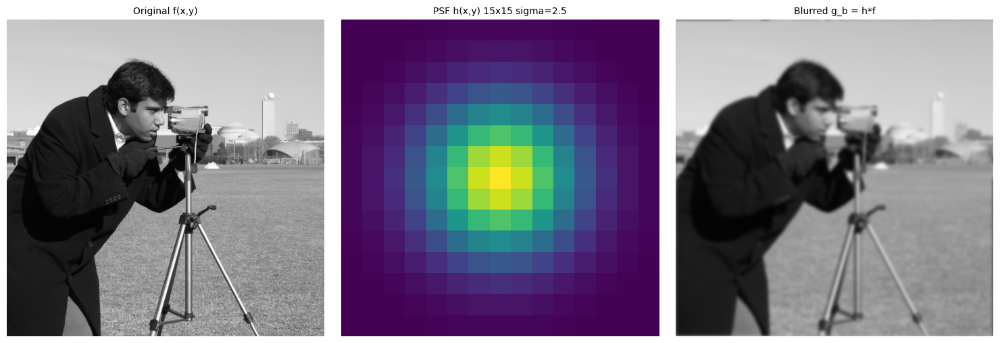

In [21]:
F1 = np.fft.fft2(f1)
gb = np.real(np.fft.ifft2(H * F1))     # blurred (circular convolution)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
show(ax[0], f1, "Original f(x,y)", vmin=0, vmax=1)
show(ax[1], psf, "PSF h(x,y) 15x15 sigma=2.5", cmap='viridis')
show(ax[2], gb, "Blurred g_b = h*f", vmin=0, vmax=1)
plt.tight_layout(); savefig("C1_blur"); plt.show()

## C-2. Add Zero-mean Gaussian Noise
$g=g_b+n$, 목표 $\mathrm{RMS}_{noise}=0.03$. 생성한 잡음의 실제 RMS를 정확히 0.03으로 맞춘다(재스케일).
**그림 관찰**: 블러+잡음(오른쪽)은 매끄러운 하늘·잔디 영역에 오돌토돌한 그레인이 뚜렷이 얹혀 왼쪽 블러 영상과 구별된다.

noise actual RMS = 0.03000 (target 0.030)


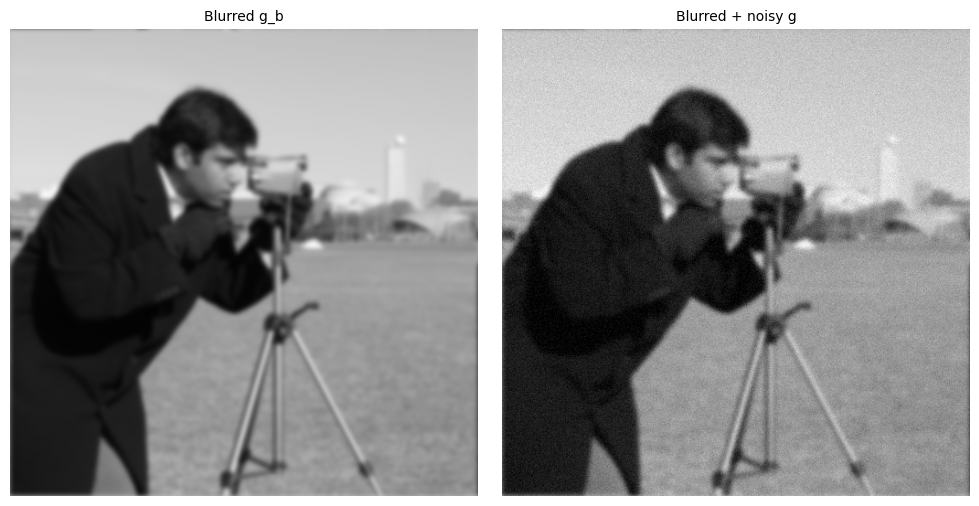

In [22]:
RMS_TARGET = 0.03
n = rng.normal(0.0, 1.0, f1.shape)
n = n - n.mean()                                  # zero-mean 보정
n = n * (RMS_TARGET / np.sqrt(np.mean(n**2)))     # 실제 RMS를 정확히 맞춤
print("noise actual RMS = %.5f (target %.3f)" % (np.sqrt(np.mean(n**2)), RMS_TARGET))
g = gb + n

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
show(ax[0], gb, "Blurred g_b", vmin=0, vmax=1)
show(ax[1], g, "Blurred + noisy g", vmin=0, vmax=1)
plt.tight_layout(); savefig("C2_noise"); plt.show()

## C-3. Restore with a Wiener Filter
$$\hat F(u,v)=\frac{H^{*}(u,v)}{|H(u,v)|^2+K}\,G(u,v),\qquad g_f=\mathcal F^{-1}\{\hat F\}.$$
$K$ 는 (잡음/신호 전력비 $S_n/S_f$ 를 상수로 근사한) 정규화 항. $K=0$ 이면 역필터(inverse filter).
**그림 관찰**: 복원(K=1e-2)은 가운데 열화 영상의 흐림이 걷혀 카메라맨·삼각대 윤곽이 또렷해지고 잡음도 억제되어 원본에 가까워진다.

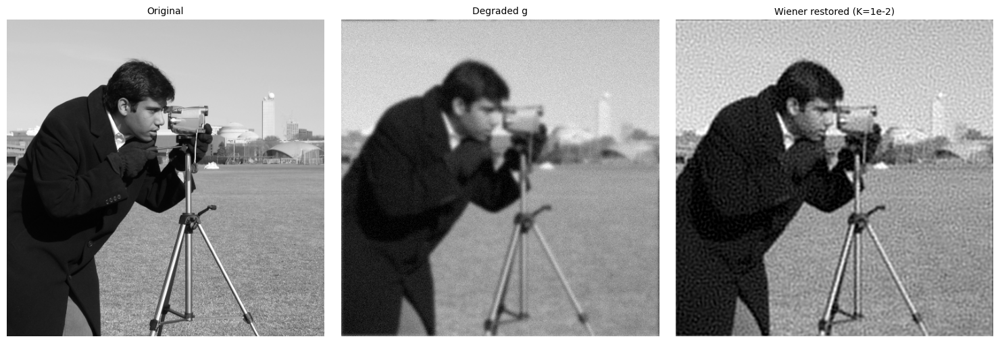

In [23]:
def wiener_restore(g, H, K):
    G = np.fft.fft2(g)
    Wf = np.conj(H) / (np.abs(H)**2 + K)
    return np.real(np.fft.ifft2(Wf * G))

Gspec = np.fft.fft2(g)
restored_demo = wiener_restore(g, H, 1e-2)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
show(ax[0], f1, "Original", vmin=0, vmax=1)
show(ax[1], g, "Degraded g", vmin=0, vmax=1)
show(ax[2], np.clip(restored_demo,0,1), "Wiener restored (K=1e-2)", vmin=0, vmax=1)
plt.tight_layout(); savefig("C3_wiener_demo"); plt.show()

## C-4. Effect of $K$
$K\in\{10^{-6},10^{-4},10^{-3},10^{-2},10^{-1}\}$ 에 대해 복원 영상과 MSE/PSNR/SSIM(원본 대비)을 비교한다.

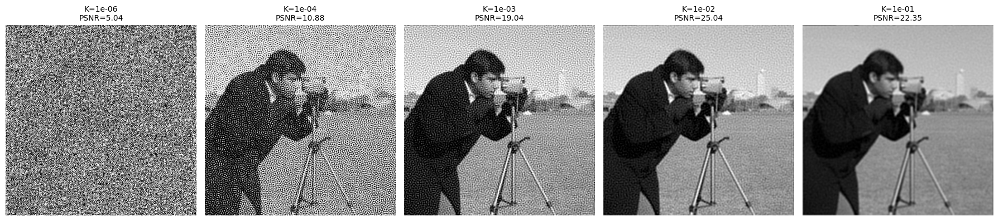

K          | MSE        | PSNR(dB)   | SSIM    
----------------------------------------------
1e-06      | 0.31364    | 5.04       | 0.0100  
1e-04      | 0.08169    | 10.88      | 0.0577  
1e-03      | 0.01246    | 19.04      | 0.2059  
1e-02      | 0.00313    | 25.04      | 0.5243    <-- best
1e-01      | 0.00582    | 22.35      | 0.6987  

Best K = 1e-02 (max PSNR)


In [24]:
Ks = [1e-6, 1e-4, 1e-3, 1e-2, 1e-1]
results = []
fig, ax = plt.subplots(1, len(Ks), figsize=(18, 4))
for i, K in enumerate(Ks):
    r = wiener_restore(g, H, K)
    rc = np.clip(r, 0, 1)
    m = mse(f1, rc); ps = psnr(f1, rc, 1.0); ss = ssim(f1, rc, 1.0)
    results.append((K, m, ps, ss))
    show(ax[i], rc, "K=%.0e\nPSNR=%.2f" % (K, ps), vmin=0, vmax=1)
plt.tight_layout(); savefig("C4_K_sweep"); plt.show()

# ----- 결과 표 (table) -----
print("%-10s | %-10s | %-10s | %-8s" % ("K", "MSE", "PSNR(dB)", "SSIM"))
print("-" * 46)
best = max(results, key=lambda t: t[2])
for K, m, ps, ss in results:
    mark = "  <-- best" if (K, m, ps, ss) == best else ""
    print("%-10.0e | %-10.5f | %-10.2f | %-8.4f%s" % (K, m, ps, ss, mark))
print("\nBest K = %.0e (max PSNR)" % best[0])

**해석 (Discuss)**
- **그림 관찰**: $K=10^{-6}$은 화면이 잡음으로 완전히 덮여 피사체가 안 보이고, $10^{-4}$는 겨우 윤곽만, $10^{-3}$부터 선명해지며 잔여 잡음, $10^{-2}$가 가장 깨끗하고 선명, $10^{-1}$은 더 매끈하지만 약간 흐릿(배경 건물이 뭉개짐)하다.
- **$K$ 가 너무 작으면** (→ 역필터): $|H|^2$ 가 0에 가까운 고주파에서 $1/|H|^2$ 가 폭발해 **잡음이 극단적으로 증폭**된다(위 $K=10^{-6}$ 에서 PSNR 음수). 선명해 보여도 잡음에 파묻힌다.
- **$K$ 가 너무 크면**: 분모가 $K$ 에 지배되어 필터가 $H^{*}/K$ 에 가까워지고, 역필터링이 약해져 **흐릿한(과평활) 복원**이 된다 → 잡음은 적지만 해상도 손실.
- **$K$ 와 잡음/선명도**: $K$ 는 **잡음 억제 ↔ 선명도(디블러링)** 사이의 트레이드오프를 조절한다. $K\approx S_n/S_f$ (잡음대신호 전력비)일 때 최적에 가깝다.
- **최적값**: 본 실험에서 **PSNR 최고는 $K=10^{-2}$**(약 25 dB)로, 잡음 증폭과 디블러의 균형이 가장 좋다. 흥미롭게도 **SSIM은 더 큰 $K=10^{-1}$ 에서 최고**인데, 이는 SSIM이 잔존 잡음(구조 교란)에 더 민감해 조금 더 평활한 복원을 선호하기 때문이다. 즉 "최적 $K$"는 어떤 지표(화소오차 vs 지각적 구조)를 중시하느냐에 따라 달라질 수 있다.

---
## 전체 요약 (Summary)
- **Part A**: 점처리·히스토그램 향상을 직접 구현. 전역(HE·스트레칭·감마) vs 국소(AHE·CLAHE)의 대비/잡음 트레이드오프를 확인했고, CLAHE가 clip+보간으로 둘을 절충함을 보였다.
- **Part B**: 합성곱 정리 $h*f\leftrightarrow HF$ 를 공간/주파수 양쪽에서 구현해 수치적으로 동일함을 확인(zero-padding으로 선형화). blur=저역통과, sharpen=고역강조임을 스펙트럼으로 해석.
- **Part C**: 가우시안 PSF + 잡음 열화 모델에 Wiener 필터를 직접 설계. 정규화 상수 $K$ 가 잡음 억제와 디블러 선명도 사이의 균형을 결정함을 정량(MSE/PSNR/SSIM)으로 확인.